# Influência da Retenção de Tela Vertical no Comportamento de Consumo

Notebook metodológico do TCC II em Bacharelado em Sistemas de Informação - UNIVILLE.

Este notebook implementa um pipeline reprodutível para investigar como duração, retenção absoluta e retenção relativa de vídeos verticais se relacionam com comportamento de consumo digital, operacionalizado por métricas de engajamento. A análise combina um estudo de caso aprofundado com 48 vídeos reais do canal de geologia de Zawacki e uma validação em escala com 48.079 registros públicos de TikTok e YouTube Shorts, licenciados sob CC BY 4.0.

Os nove resultados principais produzidos são:

1. Duração x retenção - correlação de Pearson com p-value.
2. Duração x engajamento - correlação de Pearson com p-value.
3. Comparativo entre modelos de ML - R² de treino e CV R².
4. Previsão de duração ótima via Random Forest.
5. Importância das features via feature_importances_ do Random Forest.
6. Retenção média por categoria de duração.
7. Engagement rate médio por plataforma.
8. Completion rate x engagement rate por plataforma.
9. Retenção x engajamento - correlação.

Todas as células foram estruturadas para gerar saídas numéricas diretamente citáveis no apêndice metodológico e na seção de resultados do trabalho escrito.

# Crítica da seleção a priori e ajustes metodológicos

A seleção a priori de Regressão Linear, Ridge Regression, Random Forest e Gradient Boosting é defensável porque forma uma escada de complexidade interpretável: baseline linear, regularização contra multicolinearidade, não-linearidades/interações via ensemble e boosting para padrões hierárquicos em escala. Essa escolha é metodologicamente superior à busca empírica cega de oito modelos, desde que os hiperparâmetros sejam fixados antes da avaliação e que a interpretação seja limitada ao objetivo observacional do estudo.

Há, contudo, quatro ajustes técnicos importantes:

1. O corte de 60s não deve ser defendido como limite atual do YouTube Shorts. A documentação oficial do YouTube passou a reconhecer Shorts de até 3 minutos para vídeos verticais ou quadrados enviados a partir de 15/10/2024. Portanto, neste notebook, 60s é tratado como marco histórico e analítico do formato Shorts clássico, não como limite vigente em 2025/2026. Fonte oficial: https://support.google.com/youtube/answer/15424877 e anúncio do YouTube Blog de 03/10/2024.

2. Pearson é mantido como análise principal porque os objetivos do TCC pedem associação linear com p-value, mas os resultados não devem ser interpretados como causalidade. Em distribuições muito assimétricas, Spearman pode ser usado como análise de robustez em trabalho futuro; aqui ele não substitui Pearson para preservar consistência com o plano metodológico.

3. As features de retenção são parcialmente dependentes entre si: avg_pct_watched e avg_watch_time no Dataset A, bem como completion_rate e avg_watch_time_sec no Dataset B, carregam uma relação matemática com duração. Isso torna Ridge relevante e exige cautela ao interpretar importâncias de features como efeito causal independente.

4. O Dataset B contém campos sintéticos/estimados no dicionário oficial, como dislikes sintéticos, comentários amostrais sintéticos e tempo médio assistido estimado. Ele é apropriado para validação operacional em escala e comparação entre plataformas, mas não substitui evidência causal obtida por experimento ou dados brutos auditados de analytics.

Modelos descartados: Lasso é contraproducente com apenas três variáveis escolhidas por literatura; Polinomial impõe curvas suaves e tende a overfit em n=48; KNN não oferece interpretabilidade por importância de features; Árvore única é instável e dominada por Random Forest em variância e robustez.

# Seção 1 - Imports e configurações

In [1]:
# [Código] Importação de bibliotecas com comentários explicativos
# Esta célula reúne bibliotecas estatísticas, de machine learning e visualização.
# As importações ficam no início para tornar dependências e ambiente auditáveis.

%matplotlib inline

from pathlib import Path
from collections import OrderedDict
import math
import warnings

import numpy as np
import pandas as pd
from IPython.display import display, Markdown

from scipy import stats

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
pd.set_option('display.precision', 4)

print(f'Diretório de trabalho: {BASE_DIR}')
print(f'Diretório de saída: {OUTPUT_DIR}')
print('Ambiente configurado com random_state = 42.')

Diretório de trabalho: C:\Users\Pichau\OneDrive\Documentos\TCC\Projeto Final
Diretório de saída: C:\Users\Pichau\OneDrive\Documentos\TCC\Projeto Final\outputs
Ambiente configurado com random_state = 42.


In [2]:
# [Código] Configuração de paleta visual e parâmetros globais
# A paleta é sóbria e consistente para preservar leitura acadêmica em HTML/PDF.
# Os gráficos serão salvos em alta resolução para uso no apêndice.

sns.set_theme(style='whitegrid', context='notebook')
PALETTE = {
    'TikTok': '#111111',
    'YouTube': '#D32F2F',
    'Zawacki': '#2A7F62',
    'Combinado': '#3B5B92'
}
sns.set_palette(['#2A7F62', '#3B5B92', '#D32F2F', '#F2A541'])

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 10,
    'legend.frameon': False,
})

print('Configuração visual aplicada.')

Configuração visual aplicada.


# Seção 2 - Coleta de Dados

In [3]:
# [Código] Leitura do Dataset A (Zawacki) com encoding='utf-8-sig'
# O encoding utf-8-sig remove o BOM e evita erros silenciosos em nomes de colunas.

DATASET_A_PATH = BASE_DIR / 'TikTokData_Video_Uploads.csv'
if not DATASET_A_PATH.exists():
    raise FileNotFoundError(f'Dataset A não encontrado em: {DATASET_A_PATH}')

df_zawacki_raw = pd.read_csv(DATASET_A_PATH, encoding='utf-8-sig')

print('Dataset A - Zawacki carregado.')
print(f'Shape bruto: {df_zawacki_raw.shape}')
display(df_zawacki_raw.head())

Dataset A - Zawacki carregado.
Shape bruto: (48, 26)


,Video Topic,Filmed By,Date Published,Day of Week,Days Since Upload,Time (MST),Duration (s),Views,Likes,Comments,Shares,Total Play Time (hr),Average Watch Time (s),Avg. % Watched,% Watched Full Video,Reached Audience,ER Likes (%),ER Comments (%),ER Shares (%),For You Page (%),Personal Profile (%),Following (%),Hashtag (%),% Unknown,Hashtags,Views.1
0,DEM resolution and high-res topography (San An...,Emily,2021-10-08,Friday,119,13:15:00,76.95,2422,159,6,5,14.93,22.1,28.7199,8.38,2620,6.0687,0.2290,0.1908,38,38,7,0,17,"geology, geophysics, topography, lidar, satellite",2422
1,GMV Hawaii EQ (10/10/21) seismic waves,Wendy,2021-10-11,Monday,116,09:32:00,29.70,372300,43900,558,1066,2609.27,25.1,84.5118,50.43,348926,12.5815,0.1599,0.3055,98,1,0,0,1,"earthquake, hawaii, data, seismology, geophysics",372300
2,"Attending a scientific meeting, GSA",Emily,2021-10-12,Tuesday,115,11:10:00,60.14,1539,87,8,9,6.40,14.8,24.6092,6.04,1502,5.7923,0.5326,0.5992,13,71,7,1,8,"geology, geologist, geoscience, gsa2021, geoph...",1539
3,Earthquake yoga (types of seismic waves),Wendy,2021-10-13,Wednesday,114,12:03:00,59.19,1511,58,6,6,4.40,10.5,17.7395,5.74,1411,4.1106,0.4252,0.4252,11,79,5,1,4,"seismology, geophysics, yoga, earthquake",1511
4,Types of faults,Wendy,2021-10-14,Thursday,113,12:05:00,52.24,1695,134,3,2,8.93,19.0,36.3706,21.34,1582,8.4703,0.1896,0.1264,10,75,9,0,6,"earthquake, geology, faults, geophysics",1695


In [ ]:
# [Código] Leitura do Dataset B (Público)
# O dicionário é carregado junto para documentar a origem das variáveis usadas.

DATASET_B_PATH = BASE_DIR / 'youtube_shorts_tiktok_trends_2025.csv'
DICTIONARY_CANDIDATES = [BASE_DIR / 'DATA_DICTIONARY__1_.csv', BASE_DIR / 'DATA_DICTIONARY (1).csv', BASE_DIR / 'DATA_DICTIONARY.csv']
DATA_DICTIONARY_PATH = next((p for p in DICTIONARY_CANDIDATES if p.exists()), None)

if not DATASET_B_PATH.exists():
    raise FileNotFoundError(f'Dataset B não encontrado em: {DATASET_B_PATH}')
if DATA_DICTIONARY_PATH is None:
    raise FileNotFoundError('Dicionário de dados não encontrado. Nomes esperados: DATA_DICTIONARY__1_.csv, DATA_DICTIONARY (1).csv ou DATA_DICTIONARY.csv')

df_public_raw = pd.read_csv(DATASET_B_PATH)
df_dictionary = pd.read_csv(DATA_DICTIONARY_PATH)

print('Dataset B - Público carregado.')
print(f'Shape bruto: {df_public_raw.shape}')
print(f'Dicionário oficial: {DATA_DICTIONARY_PATH.name}, shape: {df_dictionary.shape}')
display(df_public_raw.head())
display(df_dictionary.head(12))

Dataset B - Público carregado.
Shape bruto: (48079, 58)
Dicionário oficial: DATA_DICTIONARY (1).csv, shape: (58, 2)


,platform,country,region,language,category,hashtag,title_keywords,author_handle,sound_type,music_track,week_of_year,duration_sec,views,likes,comments,shares,saves,engagement_rate,trend_label,source_hint,notes,device_type,upload_hour,genre,trend_duration_days,trend_type,engagement_velocity,dislikes,comment_ratio,share_rate,save_rate,like_dislike_ratio,publish_dayofweek,publish_period,event_season,tags,sample_comments,creator_avg_views,creator_tier,season,publish_date_approx,year_month,title,title_length,has_emoji,avg_watch_time_sec,completion_rate,device_brand,traffic_source,is_weekend,row_id,engagement_total,like_rate,dislike_rate,engagement_per_1k,engagement_like_rate,engagement_comment_rate,engagement_share_rate
0,TikTok,Jp,Asia,ja,Gaming,#Lifestyle,Night Routine — College,NextVision,trending,8bit loop,1,40,252497,21755,3170,1977,3415,0.1201,rising,TikTok Creative Center,split-screen,Android,15,Lifestyle,4,Short,63124.25,1011,0.0126,0.0078,0.0135,21.4970,Saturday,Afternoon,Regular,"daily, lifestyle, motivation",ずっと見ちゃう😂,96474.3,Mid,Spring,2025-01-04,2025-01,Night Routine — Productivity 🏖️,31,1,25.8,0.645,iPhone,External,1,2e681528d17a1fe1986857942536ec27,30317,0.0862,0.0040,120.069,0.0862,0.0126,0.0078
1,TikTok,Se,Europe,sv,Food,#Sports,Morning Routine — College,DailyVlogsDiego,trending,Street vibe,1,18,270580,23080,2124,2108,3265,0.1130,declining,TikTok Creative Center,greenscreen,Android,3,Sports,56,Evergreen,4831.79,655,0.0078,0.0078,0.0121,35.1829,Wednesday,Night,Regular,"gym, football, workout",This is fire 🔥,104638.4,Mid,Fall,2025-01-01,2025-01,Football skills in 60s 📱,24,1,10.4,0.578,iPhone,Search,0,2e35fa0b2978b9cae635839c1d4e9e74,30577,0.0853,0.0024,113.005,0.0853,0.0078,0.0078
2,TikTok,Za,Africa,en,Art,#Workout,Night Routine — College,BeyondHub,licensed,Gallery pad,1,22,7385,363,33,38,69,0.0681,seasonal,TikTok Creative Center,subtitles,Android,15,Sports,11,Medium,671.36,12,0.0045,0.0051,0.0093,27.9231,Sunday,Afternoon,Regular,"football, gym, workout",Instant like!,108139.9,Mid,Fall,2025-01-05,2025-01,Football skills in 60s,22,0,11.7,0.532,Huawei,External,1,0d88a011235a82244995ef52961f9502,503,0.0492,0.0016,68.111,0.0492,0.0045,0.0051
3,TikTok,Kr,Asia,ko,News,#Esports,Best Settings for Fortnite,NextHub,original,Neutral piano,1,36,72377,6243,811,383,391,0.1082,declining,Open Web Samples,cinematic b-roll,Android,15,Gaming,10,Medium,7237.70,229,0.0112,0.0053,0.0054,27.1435,Friday,Afternoon,SummerBreak,"fps, esports, clips, gaming, valorant, highlights",Can’t stop watching 😂,102133.2,Mid,Summer,2025-01-03,2025-01,Pro Tips for Valorant in 60s 🎮,30,1,23.7,0.658,Huawei,Search,1,e15cff7621ed3f9eb9d2c97c841be0f3,7828,0.0863,0.0032,108.156,0.0863,0.0112,0.0053
4,TikTok,Au,Oceania,en,Beauty,#Comedy,When your friend is Beginners,LucasOfficial,licensed,Soft glam loop,1,35,16174,832,68,67,204,0.0724,seasonal,TikTok Creative Center,text-to-speech,Android,18,Comedy,6,Short,2695.67,19,0.0042,0.0041,0.0126,41.6000,Saturday,Evening,Regular,"comedy, relatable, sketch",So underrated!,87549.4,Mid,Fall,2025-01-04,2025-01,POV: Budget 😂,13,1,24.6,0.703,Huawei,ForYou,1,d696b4f0a50ea70e7cb5021be7e198ec,1171,0.0514,0.0012,72.400,0.0514,0.0042,0.0041


,column,description
0,platform,Platform (TikTok/YouTube)
1,country,Country ISO-2 code
2,region,Region macro label (if available)
3,language,Primary language inferred from country (fallba...
4,category,Video category (if available)
5,hashtag,Primary hashtag aligned with genre
6,title_keywords,Short realistic title-like keywords
7,author_handle,"Creator handle/channel (brand-like, synthetic)"
8,sound_type,Sound type (if present)
9,music_track,Music track (if present)


In [5]:
# [Código] Verificação inicial (shape, head, tipos)
# Esta célula registra evidências de schema antes de qualquer transformação.

print('Dataset A - shape e tipos')
print(df_zawacki_raw.shape)
display(df_zawacki_raw.dtypes.to_frame('dtype').T)

display(df_zawacki_raw.head(3))

print()
print('Dataset B - shape e tipos')
print(df_public_raw.shape)
display(df_public_raw.dtypes.to_frame('dtype').T)

display(df_public_raw.head(3))

print()
print('Plataformas no Dataset B')
display(df_public_raw['platform'].value_counts(dropna=False).to_frame('n'))

print()
print('Colunas usadas no estudo segundo o DATA_DICTIONARY oficial')
cols_interesse = ['platform', 'duration_sec', 'views', 'likes', 'comments', 'shares', 'saves', 'engagement_rate', 'avg_watch_time_sec', 'completion_rate', 'category', 'creator_tier', 'traffic_source', 'publish_dayofweek']
display(df_dictionary[df_dictionary['column'].isin(cols_interesse)])

Dataset A - shape e tipos
(48, 26)


,Video Topic,Filmed By,Date Published,Day of Week,Days Since Upload,Time (MST),Duration (s),Views,Likes,Comments,Shares,Total Play Time (hr),Average Watch Time (s),Avg. % Watched,% Watched Full Video,Reached Audience,ER Likes (%),ER Comments (%),ER Shares (%),For You Page (%),Personal Profile (%),Following (%),Hashtag (%),% Unknown,Hashtags,Views.1
dtype,str,str,str,str,int64,str,float64,int64,int64,int64,int64,float64,float64,float64,float64,int64,float64,float64,float64,int64,int64,int64,int64,int64,str,int64


,Video Topic,Filmed By,Date Published,Day of Week,Days Since Upload,Time (MST),Duration (s),Views,Likes,Comments,Shares,Total Play Time (hr),Average Watch Time (s),Avg. % Watched,% Watched Full Video,Reached Audience,ER Likes (%),ER Comments (%),ER Shares (%),For You Page (%),Personal Profile (%),Following (%),Hashtag (%),% Unknown,Hashtags,Views.1
0,DEM resolution and high-res topography (San An...,Emily,2021-10-08,Friday,119,13:15:00,76.95,2422,159,6,5,14.93,22.1,28.7199,8.38,2620,6.0687,0.2290,0.1908,38,38,7,0,17,"geology, geophysics, topography, lidar, satellite",2422
1,GMV Hawaii EQ (10/10/21) seismic waves,Wendy,2021-10-11,Monday,116,09:32:00,29.70,372300,43900,558,1066,2609.27,25.1,84.5118,50.43,348926,12.5815,0.1599,0.3055,98,1,0,0,1,"earthquake, hawaii, data, seismology, geophysics",372300
2,"Attending a scientific meeting, GSA",Emily,2021-10-12,Tuesday,115,11:10:00,60.14,1539,87,8,9,6.40,14.8,24.6092,6.04,1502,5.7923,0.5326,0.5992,13,71,7,1,8,"geology, geologist, geoscience, gsa2021, geoph...",1539



Dataset B - shape e tipos
(48079, 58)


,platform,country,region,language,category,hashtag,title_keywords,author_handle,sound_type,music_track,week_of_year,duration_sec,views,likes,comments,shares,saves,engagement_rate,trend_label,source_hint,notes,device_type,upload_hour,genre,trend_duration_days,trend_type,engagement_velocity,dislikes,comment_ratio,share_rate,save_rate,like_dislike_ratio,publish_dayofweek,publish_period,event_season,tags,sample_comments,creator_avg_views,creator_tier,season,publish_date_approx,year_month,title,title_length,has_emoji,avg_watch_time_sec,completion_rate,device_brand,traffic_source,is_weekend,row_id,engagement_total,like_rate,dislike_rate,engagement_per_1k,engagement_like_rate,engagement_comment_rate,engagement_share_rate
dtype,str,str,str,str,str,str,str,str,str,str,int64,int64,int64,int64,int64,int64,int64,float64,str,str,str,str,int64,str,int64,str,float64,int64,float64,float64,float64,float64,str,str,str,str,str,float64,str,str,str,str,str,int64,int64,float64,float64,str,str,int64,str,int64,float64,float64,float64,float64,float64,float64


,platform,country,region,language,category,hashtag,title_keywords,author_handle,sound_type,music_track,week_of_year,duration_sec,views,likes,comments,shares,saves,engagement_rate,trend_label,source_hint,notes,device_type,upload_hour,genre,trend_duration_days,trend_type,engagement_velocity,dislikes,comment_ratio,share_rate,save_rate,like_dislike_ratio,publish_dayofweek,publish_period,event_season,tags,sample_comments,creator_avg_views,creator_tier,season,publish_date_approx,year_month,title,title_length,has_emoji,avg_watch_time_sec,completion_rate,device_brand,traffic_source,is_weekend,row_id,engagement_total,like_rate,dislike_rate,engagement_per_1k,engagement_like_rate,engagement_comment_rate,engagement_share_rate
0,TikTok,Jp,Asia,ja,Gaming,#Lifestyle,Night Routine — College,NextVision,trending,8bit loop,1,40,252497,21755,3170,1977,3415,0.1201,rising,TikTok Creative Center,split-screen,Android,15,Lifestyle,4,Short,63124.25,1011,0.0126,0.0078,0.0135,21.4970,Saturday,Afternoon,Regular,"daily, lifestyle, motivation",ずっと見ちゃう😂,96474.3,Mid,Spring,2025-01-04,2025-01,Night Routine — Productivity 🏖️,31,1,25.8,0.645,iPhone,External,1,2e681528d17a1fe1986857942536ec27,30317,0.0862,0.0040,120.069,0.0862,0.0126,0.0078
1,TikTok,Se,Europe,sv,Food,#Sports,Morning Routine — College,DailyVlogsDiego,trending,Street vibe,1,18,270580,23080,2124,2108,3265,0.1130,declining,TikTok Creative Center,greenscreen,Android,3,Sports,56,Evergreen,4831.79,655,0.0078,0.0078,0.0121,35.1829,Wednesday,Night,Regular,"gym, football, workout",This is fire 🔥,104638.4,Mid,Fall,2025-01-01,2025-01,Football skills in 60s 📱,24,1,10.4,0.578,iPhone,Search,0,2e35fa0b2978b9cae635839c1d4e9e74,30577,0.0853,0.0024,113.005,0.0853,0.0078,0.0078
2,TikTok,Za,Africa,en,Art,#Workout,Night Routine — College,BeyondHub,licensed,Gallery pad,1,22,7385,363,33,38,69,0.0681,seasonal,TikTok Creative Center,subtitles,Android,15,Sports,11,Medium,671.36,12,0.0045,0.0051,0.0093,27.9231,Sunday,Afternoon,Regular,"football, gym, workout",Instant like!,108139.9,Mid,Fall,2025-01-05,2025-01,Football skills in 60s,22,0,11.7,0.532,Huawei,External,1,0d88a011235a82244995ef52961f9502,503,0.0492,0.0016,68.111,0.0492,0.0045,0.0051



Plataformas no Dataset B


,n
platform,
TikTok,28844
YouTube,19235



Colunas usadas no estudo segundo o DATA_DICTIONARY oficial


,column,description
0,platform,Platform (TikTok/YouTube)
4,category,Video category (if available)
11,duration_sec,Shorts-style duration in seconds (TikTok ~5–75...
12,views,Total views
13,likes,Likes count
14,comments,Comments count
15,shares,Shares count
16,saves,Saves count
17,engagement_rate,(likes+comments+shares+saves) / views
32,publish_dayofweek,Day of week of publish_date


# Seção 3 - Limpeza e Transformação (ETL)

In [6]:
# [Código] Limpeza Dataset A (renomeação, conversão numérica, dropna)
# A limpeza preserva apenas variáveis analíticas necessárias e evita coerções implícitas.

rename_zawacki = {
    'Duration (s)': 'duration',
    'Views': 'views',
    'Likes': 'likes',
    'Comments': 'comments',
    'Shares': 'shares',
    'Average Watch Time (s)': 'avg_watch_time',
    'Avg. % Watched': 'avg_pct_watched',
    '% Watched Full Video': 'pct_full_video',
    'ER Likes (%)': 'er_likes',
    'ER Comments (%)': 'er_comments',
    'ER Shares (%)': 'er_shares',
    'Video Topic': 'video_topic',
    'Date Published': 'date_published',
}

df_zawacki = df_zawacki_raw.copy()
df_zawacki.columns = [c.strip() for c in df_zawacki.columns]
df_zawacki = df_zawacki.rename(columns=rename_zawacki)

required_zawacki = ['duration', 'views', 'likes', 'comments', 'shares', 'avg_watch_time', 'avg_pct_watched', 'pct_full_video', 'er_likes']
missing_zawacki = [c for c in required_zawacki if c not in df_zawacki.columns]
if missing_zawacki:
    raise KeyError(f'Colunas ausentes no Dataset A após renomeação: {missing_zawacki}')

for col in required_zawacki:
    df_zawacki[col] = pd.to_numeric(df_zawacki[col], errors='coerce')

n_before = len(df_zawacki)
df_zawacki = df_zawacki.dropna(subset=required_zawacki).copy()
df_zawacki = df_zawacki[
    (df_zawacki['duration'] > 0) &
    (df_zawacki['views'] > 0) &
    (df_zawacki['avg_watch_time'] >= 0) &
    (df_zawacki['avg_pct_watched'].between(0, 200)) &
    (df_zawacki['er_likes'] >= 0)
].copy()

print('Dataset A limpo.')
print(f'Linhas antes: {n_before} | depois: {len(df_zawacki)} | removidas: {n_before - len(df_zawacki)}')
display(df_zawacki[required_zawacki].describe().T)

Dataset A limpo.
Linhas antes: 48 | depois: 48 | removidas: 0


,count,mean,std,min,25%,50%,75%,max
duration,48.0,57.1788,28.8467,8.7800,39.3800,54.9600,64.5350,147.0500
views,48.0,43885.5000,122503.8841,522.0000,1812.2500,2386.5000,6696.5000,684100.0000
likes,48.0,4853.4583,16631.5851,27.0000,133.2500,216.5000,698.2500,104600.0000
comments,48.0,74.5625,203.1572,1.0000,5.0000,10.0000,28.5000,1209.0000
shares,48.0,107.1667,376.1692,0.0000,2.0000,5.5000,18.2500,2332.0000
avg_watch_time,48.0,23.4069,12.0136,5.4000,14.8000,21.7500,26.5000,62.7000
avg_pct_watched,48.0,44.1573,15.9241,17.7395,33.1626,41.7332,53.1648,84.5118
pct_full_video,48.0,19.2963,11.6027,2.3900,9.9150,18.4600,23.8825,50.4300
er_likes,48.0,9.5745,3.7126,4.0927,6.5345,8.6038,11.8092,20.1075


In [7]:
# [Código] Limpeza Dataset B (filtro de outliers, dropna, separação por plataforma)
# As definições de engagement_rate e completion_rate seguem o DATA_DICTIONARY oficial.

numeric_public = ['duration_sec', 'views', 'likes', 'comments', 'shares', 'saves', 'engagement_rate', 'avg_watch_time_sec', 'completion_rate']
required_public = ['platform'] + numeric_public

df_public = df_public_raw.copy()
df_public.columns = [c.strip() for c in df_public.columns]

missing_public = [c for c in required_public if c not in df_public.columns]
if missing_public:
    raise KeyError(f'Colunas ausentes no Dataset B: {missing_public}')

for col in numeric_public:
    df_public[col] = pd.to_numeric(df_public[col], errors='coerce')

df_public['platform'] = df_public['platform'].astype(str).str.strip()

# Recalcula métricas oficiais para auditar consistência e preencher eventuais nulos.
engagement_calc = (df_public['likes'] + df_public['comments'] + df_public['shares'] + df_public['saves']) / df_public['views'].replace(0, np.nan)
completion_calc = df_public['avg_watch_time_sec'] / df_public['duration_sec'].replace(0, np.nan)

diff_engagement = (df_public['engagement_rate'] - engagement_calc).abs().max(skipna=True)
diff_completion = (df_public['completion_rate'] - completion_calc).abs().max(skipna=True)

print(f'Diferença máxima engagement_rate oficial vs recalculado: {diff_engagement:.8f}')
print(f'Diferença máxima completion_rate oficial vs recalculado: {diff_completion:.8f}')

df_public['engagement_rate'] = df_public['engagement_rate'].fillna(engagement_calc)
df_public['completion_rate'] = df_public['completion_rate'].fillna(completion_calc)

n_before = len(df_public)
df_public_clean = df_public.dropna(subset=required_public).copy()
df_public_clean = df_public_clean[
    (df_public_clean['views'] > 0) &
    (df_public_clean['duration_sec'] > 0) &
    (df_public_clean['avg_watch_time_sec'] >= 0) &
    (df_public_clean['engagement_rate'].between(0, 1)) &
    (df_public_clean['completion_rate'].between(0, 1)) &
    (df_public_clean['platform'].isin(['TikTok', 'YouTube']))
].copy()

# Amostra fixa para acelerar ML, preservando o dataset completo para EDA.
df_public_ml = df_public_clean.sample(n=min(15000, len(df_public_clean)), random_state=RANDOM_STATE).copy()

df_tiktok_full = df_public_clean[df_public_clean['platform'] == 'TikTok'].copy()
df_youtube_full = df_public_clean[df_public_clean['platform'] == 'YouTube'].copy()
df_tiktok_ml = df_public_ml[df_public_ml['platform'] == 'TikTok'].copy()
df_youtube_ml = df_public_ml[df_public_ml['platform'] == 'YouTube'].copy()

print('Dataset B limpo.')
print(f'Linhas antes: {n_before} | depois: {len(df_public_clean)} | removidas: {n_before - len(df_public_clean)}')
print(f'Amostra para ML: {len(df_public_ml)} linhas')
print(f'TikTok full: {len(df_tiktok_full)} | YouTube full: {len(df_youtube_full)}')
print(f'TikTok ML: {len(df_tiktok_ml)} | YouTube ML: {len(df_youtube_ml)}')
display(df_public_clean.groupby('platform')[numeric_public].agg(['count', 'mean', 'median']).round(4))

Diferença máxima engagement_rate oficial vs recalculado: 0.00000050
Diferença máxima completion_rate oficial vs recalculado: 0.00050000


Dataset B limpo.
Linhas antes: 48079 | depois: 48079 | removidas: 0
Amostra para ML: 15000 linhas
TikTok full: 28844 | YouTube full: 19235
TikTok ML: 9044 | YouTube ML: 5956


duration_sec                  views                       likes                    comments                  shares                   saves                   \
                count     mean median  count        mean   median  count       mean  median    count      mean median  count      mean median  count      mean median   
platform                                                                                                                                                                
TikTok          28844  30.2403   27.0  28844  99799.8126  59564.0  28844  7009.7974  4043.5    28844  768.9364  432.0  28844  676.5974  382.0  28844  721.7369  379.0   
YouTube         19235  40.8610   37.0  19235  98532.4073  59718.0  19235  3830.1963  2205.0    19235  418.3006  235.0  19235  368.8695  209.0  19235  395.1311  207.0   

         engagement_rate                 avg_watch_time_sec                 completion_rate                 
                   count    mean  median              count     mean median           count    mean median  
platform                                                                                                    
TikTok             28844  0.0918  0.0888              28844  20.4468   18.4           28844  0.6760  0.677  
YouTube            19235  0.0509  0.0491              19235  23.4854   21.2           19235  0.5744  0.574

# Seção 4 - Feature Engineering

In [8]:
# [Código] Features derivadas Zawacki (engagement_total, retention_score, log_views, duration_category)
# As features derivadas tornam explícitas as dimensões de consumo: alcance, retenção e engajamento.

DURATION_BINS = [0, 15, 60, 300]
DURATION_LABELS = ['Muito curto (≤15s)', 'Curto-Médio (16-60s)', 'Longo (>60s)']

df_zawacki['engagement_total'] = df_zawacki[['likes', 'comments', 'shares']].sum(axis=1)
df_zawacki['retention_score'] = df_zawacki['avg_pct_watched'] / 100
# log1p reduz assimetria de views sem perder vídeos com baixa audiência.
df_zawacki['log_views'] = np.log1p(df_zawacki['views'])
df_zawacki['duration_category'] = pd.cut(
    df_zawacki['duration'],
    bins=DURATION_BINS,
    labels=DURATION_LABELS,
    include_lowest=True,
    right=True
)

print('Features derivadas do Dataset A criadas.')
print('Distribuição por categoria de duração:')
display(df_zawacki['duration_category'].value_counts(dropna=False).to_frame('n'))
display(df_zawacki[['duration', 'avg_watch_time', 'avg_pct_watched', 'retention_score', 'engagement_total', 'er_likes', 'log_views', 'duration_category']].head())

Features derivadas do Dataset A criadas.
Distribuição por categoria de duração:


,n
duration_category,
Curto-Médio (16-60s),29
Longo (>60s),17
Muito curto (≤15s),2


,duration,avg_watch_time,avg_pct_watched,retention_score,engagement_total,er_likes,log_views,duration_category
0,76.95,22.1,28.7199,0.2872,170,6.0687,7.7928,Longo (>60s)
1,29.70,25.1,84.5118,0.8451,45524,12.5815,12.8275,Curto-Médio (16-60s)
2,60.14,14.8,24.6092,0.2461,104,5.7923,7.3395,Longo (>60s)
3,59.19,10.5,17.7395,0.1774,70,4.1106,7.3212,Curto-Médio (16-60s)
4,52.24,19.0,36.3706,0.3637,139,8.4703,7.4360,Curto-Médio (16-60s)


In [9]:
# [Código] Features derivadas Dataset Público (log_views, duration_category)
# A mesma categorização de duração é aplicada para permitir comparação entre datasets.

def adicionar_features_publicas(df):
    df = df.copy()
    df['engagement_total_calc'] = df[['likes', 'comments', 'shares', 'saves']].sum(axis=1)
    df['log_views'] = np.log1p(df['views'])
    df['duration_category'] = pd.cut(
        df['duration_sec'],
        bins=DURATION_BINS,
        labels=DURATION_LABELS,
        include_lowest=True,
        right=True
    )
    return df

df_public_clean = adicionar_features_publicas(df_public_clean)
df_public_ml = adicionar_features_publicas(df_public_ml)
df_tiktok_full = df_public_clean[df_public_clean['platform'] == 'TikTok'].copy()
df_youtube_full = df_public_clean[df_public_clean['platform'] == 'YouTube'].copy()
df_tiktok_ml = df_public_ml[df_public_ml['platform'] == 'TikTok'].copy()
df_youtube_ml = df_public_ml[df_public_ml['platform'] == 'YouTube'].copy()

print('Features derivadas do Dataset B criadas.')
print('Distribuição por plataforma e categoria de duração:')
display(pd.crosstab(df_public_clean['platform'], df_public_clean['duration_category'], margins=True))

fora_recorte = df_public_clean['duration_category'].isna().sum()
if fora_recorte > 0:
    print(f'Atenção: {fora_recorte} vídeos ficaram fora do recorte 0-300s e foram mantidos com categoria nula para auditoria.')

Features derivadas do Dataset B criadas.
Distribuição por plataforma e categoria de duração:


duration_category,Muito curto (≤15s),Curto-Médio (16-60s),Longo (>60s),All
platform,,,,
TikTok,3022,24642,1180,28844
YouTube,522,15957,2756,19235
All,3544,40599,3936,48079


# Justificativa teórica das categorias de duração

A categorização usa três faixas: Muito curto (≤15s), Curto-Médio (16-60s) e Longo (>60s, até 300s no recorte operacional). A faixa de 15s representa a gramática inicial do TikTok e de formatos ultracurtos discutidos em estudos sobre adaptação jornalística e comunicacional ao TikTok, como Vázquez-Herrero, Negreira-Rey e López-García. A faixa de 60s representa o Shorts clássico e a fronteira histórica entre vídeos curtos nativos e vídeos verticais mais longos. A faixa acima de 60s captura conteúdos que extrapolam a lógica ultracurta e podem exigir retenção narrativa diferente.

A ressalva metodológica é relevante: como o YouTube passou a classificar vídeos verticais/quadrados de até 180s como Shorts a partir de 15/10/2024, o corte de 60s é mantido como categoria analítica histórica, não como regra técnica atual. A referência Heitmayer (2025), conforme o referencial do TCC, é usada para sustentar a divisão tripartida entre vídeos muito curtos, curtos/médios e verticais longos.

# Seção 5 - Análise Exploratória (EDA)

In [10]:
# [Código] Estatísticas descritivas Zawacki
# Esta célula quantifica o estudo de caso antes de testar hipóteses estatísticas.

cols_desc_z = ['duration', 'views', 'likes', 'comments', 'shares', 'avg_watch_time', 'avg_pct_watched', 'pct_full_video', 'er_likes', 'engagement_total']

desc_zawacki = df_zawacki[cols_desc_z].describe().T.round(4)
print('Estatísticas descritivas - Dataset A')
display(desc_zawacki)

retencao_por_categoria_z = (
    df_zawacki.groupby('duration_category', observed=False)
    .agg(
        n=('duration', 'size'),
        duracao_media=('duration', 'mean'),
        retencao_media_pct=('avg_pct_watched', 'mean'),
        watch_time_medio=('avg_watch_time', 'mean'),
        er_likes_medio=('er_likes', 'mean')
    )
    .round(4)
)

print('Insight 6 - Retenção média por categoria de duração no Dataset A')
display(retencao_por_categoria_z)

Estatísticas descritivas - Dataset A


,count,mean,std,min,25%,50%,75%,max
duration,48.0,57.1788,28.8467,8.7800,39.3800,54.9600,64.5350,147.0500
views,48.0,43885.5000,122503.8841,522.0000,1812.2500,2386.5000,6696.5000,684100.0000
likes,48.0,4853.4583,16631.5851,27.0000,133.2500,216.5000,698.2500,104600.0000
comments,48.0,74.5625,203.1572,1.0000,5.0000,10.0000,28.5000,1209.0000
shares,48.0,107.1667,376.1692,0.0000,2.0000,5.5000,18.2500,2332.0000
avg_watch_time,48.0,23.4069,12.0136,5.4000,14.8000,21.7500,26.5000,62.7000
avg_pct_watched,48.0,44.1573,15.9241,17.7395,33.1626,41.7332,53.1648,84.5118
pct_full_video,48.0,19.2962,11.6027,2.3900,9.9150,18.4600,23.8825,50.4300
er_likes,48.0,9.5745,3.7126,4.0927,6.5345,8.6038,11.8092,20.1075
engagement_total,48.0,5035.1875,17205.5623,28.0000,139.7500,230.0000,754.2500,108141.0000


Insight 6 - Retenção média por categoria de duração no Dataset A


,n,duracao_media,retencao_media_pct,watch_time_medio,er_likes_medio
duration_category,,,,,
Muito curto (≤15s),2,9.9050,62.6336,6.0500,6.7979
Curto-Médio (16-60s),29,43.8024,47.1122,19.5838,9.6466
Longo (>60s),17,85.5588,36.9431,31.9706,9.7781


In [11]:
# [Código] Estatísticas descritivas TikTok vs YouTube no Dataset B
# A comparação por plataforma usa o dataset público limpo completo, não apenas a amostra de ML.

platform_stats = (
    df_public_clean.groupby('platform')
    .agg(
        n=('platform', 'size'),
        duracao_media=('duration_sec', 'mean'),
        duracao_mediana=('duration_sec', 'median'),
        views_mediana=('views', 'median'),
        engagement_rate_medio=('engagement_rate', 'mean'),
        completion_rate_medio=('completion_rate', 'mean'),
        watch_time_medio=('avg_watch_time_sec', 'mean')
    )
    .round(5)
)

print('Estatísticas descritivas por plataforma - Dataset B')
display(platform_stats)

engagement_por_plataforma = df_public_clean.groupby('platform')['engagement_rate'].mean().round(6)
completion_engagement_por_plataforma = df_public_clean.groupby('platform')[['completion_rate', 'engagement_rate']].mean().round(6)

print('Insight 7 - Engagement rate médio por plataforma')
for plataforma, valor in engagement_por_plataforma.items():
    print(f'{plataforma}: engagement_rate médio = {valor:.6f}')

print()
print('Insight 8 - Completion rate x Engagement rate por plataforma')
display(completion_engagement_por_plataforma)

Estatísticas descritivas por plataforma - Dataset B


,n,duracao_media,duracao_mediana,views_mediana,engagement_rate_medio,completion_rate_medio,watch_time_medio
platform,,,,,,,
TikTok,28844,30.2403,27.0,59564.0,0.0918,0.6760,20.4468
YouTube,19235,40.8610,37.0,59718.0,0.0509,0.5744,23.4854


Insight 7 - Engagement rate médio por plataforma
TikTok: engagement_rate médio = 0.091781
YouTube: engagement_rate médio = 0.050875

Insight 8 - Completion rate x Engagement rate por plataforma


,completion_rate,engagement_rate
platform,,
TikTok,0.6760,0.0918
YouTube,0.5744,0.0509


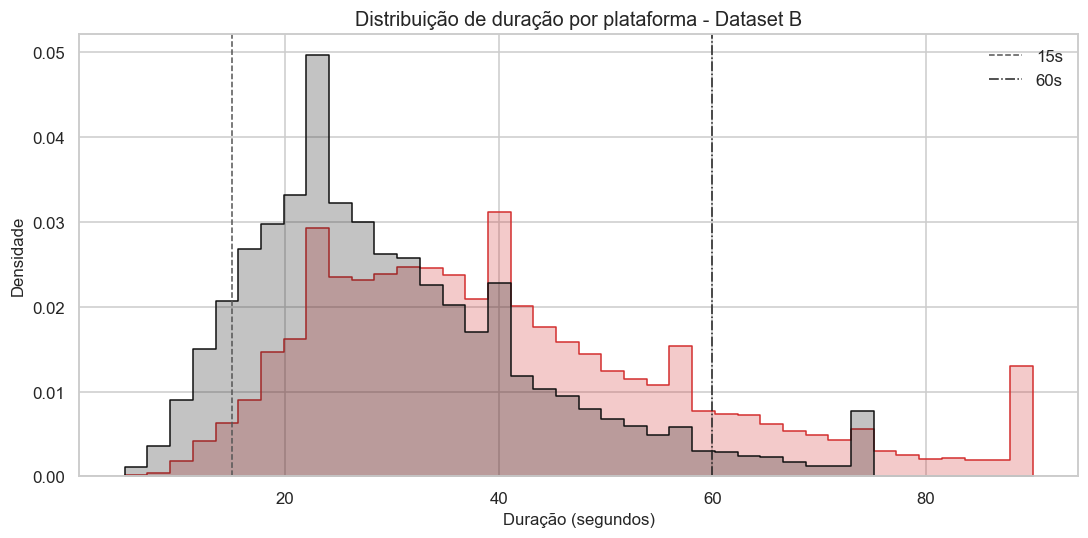

In [12]:
# [Código] Visualização: histogramas de duração por plataforma
# A distribuição de duração ajuda a interpretar os cortes 15s e 60s antes da modelagem.

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=df_public_clean,
    x='duration_sec',
    hue='platform',
    bins=40,
    element='step',
    stat='density',
    common_norm=False,
    palette=PALETTE,
    ax=ax
)
ax.axvline(15, color='#555555', linestyle='--', linewidth=1, label='15s')
ax.axvline(60, color='#222222', linestyle='-.', linewidth=1, label='60s')
ax.set_title('Distribuição de duração por plataforma - Dataset B')
ax.set_xlabel('Duração (segundos)')
ax.set_ylabel('Densidade')
ax.legend()
plt.tight_layout()
plt.show()

# [Markdown] Seção 6 - Correlações Estatísticas

# [Markdown] Explicação: por que Pearson + p-value

A correlação de Pearson mede associação linear entre duas variáveis contínuas e o p-value testa a hipótese nula de correlação populacional igual a zero. Ela é adequada ao objetivo de produzir evidência estatística clara e comparável entre duração, retenção e engajamento. Como os dados de mídias sociais tendem a ter assimetria e caudas longas, os resultados devem ser lidos como associação observacional, não como causalidade. Valores de p são reportados com marcação de significância: *** para p<0,001; ** para p<0,01; * para p<0,05; ns para p≥0,05.

In [13]:
# [Código] Função imprimir_correlacao (Pearson + p + marcação de significância)
# A função padroniza saídas para que cada correlação tenha r, p-value, n e significância.

def marcador_significancia(p_value):
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    return 'ns'


def imprimir_correlacao(df, x, y, rotulo=None):
    dados = df[[x, y]].dropna()
    if len(dados) < 3:
        raise ValueError(f'A correlação {x} x {y} requer ao menos 3 observações válidas.')
    r, p = stats.pearsonr(dados[x], dados[y])
    sig = marcador_significancia(p)
    nome = rotulo or f'{x} x {y}'
    direcao = 'positiva' if r > 0 else 'negativa' if r < 0 else 'nula'
    print(f'{nome}: r = {r:.4f}; p = {p:.6g}; n = {len(dados)}; significância = {sig}; direção = {direcao}')
    return {
        'analise': nome,
        'x': x,
        'y': y,
        'r': r,
        'p_value': p,
        'n': len(dados),
        'significancia': sig,
        'direcao': direcao
    }

print('Função de correlação pronta.')

Função de correlação pronta.

In [14]:
# [Código] Correlações no Dataset A: duração x retenção, duração x engajamento, retenção x engajamento, watch_time x engajamento
# Estes testes cobrem os Insights 1, 2 e 9 no estudo de caso real.

correlacoes_zawacki = []
correlacoes_zawacki.append(imprimir_correlacao(df_zawacki, 'duration', 'avg_pct_watched', 'Insight 1A - Duração x retenção relativa (Zawacki)'))
correlacoes_zawacki.append(imprimir_correlacao(df_zawacki, 'duration', 'er_likes', 'Insight 2A - Duração x engajamento (Zawacki)'))
correlacoes_zawacki.append(imprimir_correlacao(df_zawacki, 'avg_pct_watched', 'er_likes', 'Insight 9A - Retenção relativa x engajamento (Zawacki)'))
correlacoes_zawacki.append(imprimir_correlacao(df_zawacki, 'avg_watch_time', 'er_likes', 'Watch time absoluto x engajamento (Zawacki)'))

correlacoes_zawacki_df = pd.DataFrame(correlacoes_zawacki).round(6)
display(correlacoes_zawacki_df)

Insight 1A - Duração x retenção relativa (Zawacki): r = -0.4095; p = 0.00385243; n = 48; significância = **; direção = negativa
Insight 2A - Duração x engajamento (Zawacki): r = 0.3431; p = 0.016971; n = 48; significância = *; direção = positiva
Insight 9A - Retenção relativa x engajamento (Zawacki): r = 0.2473; p = 0.0901864; n = 48; significância = ns; direção = positiva
Watch time absoluto x engajamento (Zawacki): r = 0.5432; p = 6.62488e-05; n = 48; significância = ***; direção = positiva


,analise,x,y,r,p_value,n,significancia,direcao
0,Insight 1A - Duração x retenção relativa (Zawa...,duration,avg_pct_watched,-0.4095,3.8520e-03,48,**,negativa
1,Insight 2A - Duração x engajamento (Zawacki),duration,er_likes,0.3431,1.6971e-02,48,*,positiva
2,Insight 9A - Retenção relativa x engajamento (...,avg_pct_watched,er_likes,0.2473,9.0186e-02,48,ns,positiva
3,Watch time absoluto x engajamento (Zawacki),avg_watch_time,er_likes,0.5432,6.6000e-05,48,***,positiva


In [15]:
# [Código] Correlações no Dataset B: duração x completion, completion x engagement (geral, TikTok, YouTube)
# O dataset em escala testa se os padrões aparecem também entre plataformas.

correlacoes_publico = []
correlacoes_publico.append(imprimir_correlacao(df_public_clean, 'duration_sec', 'completion_rate', 'Insight 1B - Duração x completion rate (geral)'))
correlacoes_publico.append(imprimir_correlacao(df_public_clean, 'completion_rate', 'engagement_rate', 'Insight 9B - Completion rate x engagement rate (geral)'))

for plataforma, df_plataforma in [('TikTok', df_tiktok_full), ('YouTube', df_youtube_full)]:
    correlacoes_publico.append(imprimir_correlacao(df_plataforma, 'duration_sec', 'completion_rate', f'Insight 1B - Duração x completion rate ({plataforma})'))
    correlacoes_publico.append(imprimir_correlacao(df_plataforma, 'completion_rate', 'engagement_rate', f'Insight 8/9B - Completion x engagement ({plataforma})'))

correlacoes_publico_df = pd.DataFrame(correlacoes_publico).round(6)
display(correlacoes_publico_df)

Insight 1B - Duração x completion rate (geral): r = -0.1348; p = 1.23916e-193; n = 48079; significância = ***; direção = negativa
Insight 9B - Completion rate x engagement rate (geral): r = 0.2989; p = 0; n = 48079; significância = ***; direção = positiva
Insight 1B - Duração x completion rate (TikTok): r = 0.0041; p = 0.481062; n = 28844; significância = ns; direção = positiva
Insight 8/9B - Completion x engagement (TikTok): r = 0.0087; p = 0.139273; n = 28844; significância = ns; direção = positiva
Insight 1B - Duração x completion rate (YouTube): r = 0.0092; p = 0.203707; n = 19235; significância = ns; direção = positiva
Insight 8/9B - Completion x engagement (YouTube): r = 0.0023; p = 0.745902; n = 19235; significância = ns; direção = positiva


,analise,x,y,r,p_value,n,significancia,direcao
0,Insight 1B - Duração x completion rate (geral),duration_sec,completion_rate,-0.1348,0.0000,48079,***,negativa
1,Insight 9B - Completion rate x engagement rate...,completion_rate,engagement_rate,0.2989,0.0000,48079,***,positiva
2,Insight 1B - Duração x completion rate (TikTok),duration_sec,completion_rate,0.0041,0.4811,28844,ns,positiva
3,Insight 8/9B - Completion x engagement (TikTok),completion_rate,engagement_rate,0.0087,0.1393,28844,ns,positiva
4,Insight 1B - Duração x completion rate (YouTube),duration_sec,completion_rate,0.0092,0.2037,19235,ns,positiva
5,Insight 8/9B - Completion x engagement (YouTube),completion_rate,engagement_rate,0.0023,0.7459,19235,ns,positiva


# [Markdown] Análises de robustez e confundimento

Pearson permanece como teste principal previamente especificado. Esta subseção acrescenta verificações de robustez, sem substituir a análise principal: Spearman verifica se a conclusão permanece quando se usam posições/ranks, reduzindo sensibilidade a extremos e a relações não lineares; Kruskal-Wallis compara categorias de duração sem pressupor normalidade; e a estratificação por plataforma testa se uma associação observada no dataset combinado existe dentro de TikTok e YouTube.

Este ponto é central para a interpretação: se a correlação aparece no conjunto combinado, mas desaparece dentro de cada plataforma, a evidência é compatível com confundimento por plataforma (efeito de composição), e não com uma influência geral de retenção dentro de cada plataforma.

In [16]:
# [Código] Sensibilidade por Spearman e Kruskal-Wallis no Dataset A
# Pearson é confirmatório; os testes abaixo mostram se o sentido do achado resiste a assimetria e categorias pequenas.

def imprimir_spearman(df, x, y, rotulo):
    dados = df[[x, y]].dropna()
    rho, p = stats.spearmanr(dados[x], dados[y])
    sig = marcador_significancia(p)
    print(f'{rotulo}: rho = {rho:.4f}; p = {p:.6g}; n = {len(dados)}; significância = {sig}')
    return {'analise': rotulo, 'rho': rho, 'p_value': p, 'n': len(dados), 'significancia': sig}

spearman_zawacki = []
spearman_zawacki.append(imprimir_spearman(df_zawacki, 'duration', 'avg_pct_watched', 'Robustez - Duração x retenção relativa (Zawacki)'))
spearman_zawacki.append(imprimir_spearman(df_zawacki, 'duration', 'er_likes', 'Robustez - Duração x engajamento (Zawacki)'))
spearman_zawacki.append(imprimir_spearman(df_zawacki, 'avg_pct_watched', 'er_likes', 'Robustez - Retenção relativa x engajamento (Zawacki)'))
spearman_zawacki.append(imprimir_spearman(df_zawacki, 'avg_watch_time', 'er_likes', 'Robustez - Watch time x engajamento (Zawacki)'))

testes_categoria = []
for metrica, nome in [('avg_pct_watched', 'Retenção relativa'), ('er_likes', 'Engajamento de likes')]:
    grupos = [grupo[metrica].dropna() for _, grupo in df_zawacki.groupby('duration_category', observed=False)]
    h, p = stats.kruskal(*grupos)
    sig = marcador_significancia(p)
    testes_categoria.append({'Métrica': nome, 'Kruskal H': h, 'p_value': p, 'Significância': sig})
    print(f'Kruskal-Wallis - {nome} por categoria de duração: H = {h:.4f}; p = {p:.6g}; significância = {sig}')

spearman_zawacki_df = pd.DataFrame(spearman_zawacki).round(6)
testes_categoria_df = pd.DataFrame(testes_categoria).round(6)
display(spearman_zawacki_df)
display(testes_categoria_df)

if testes_categoria_df.loc[testes_categoria_df['Métrica'] == 'Engajamento de likes', 'p_value'].iloc[0] >= 0.05:
    print('Interpretação cautelosa: as categorias de duração não apresentam diferença estatisticamente significativa de engajamento no Dataset A.')
print('A categoria Muito curto contém somente 2 vídeos; suas médias são exploratórias e não devem ser generalizadas.')

Robustez - Duração x retenção relativa (Zawacki): rho = -0.4728; p = 0.000689637; n = 48; significância = ***
Robustez - Duração x engajamento (Zawacki): rho = 0.1692; p = 0.250411; n = 48; significância = ns
Robustez - Retenção relativa x engajamento (Zawacki): rho = 0.3529; p = 0.0138817; n = 48; significância = *
Robustez - Watch time x engajamento (Zawacki): rho = 0.5874; p = 1.13898e-05; n = 48; significância = ***
Kruskal-Wallis - Retenção relativa por categoria de duração: H = 6.7671; p = 0.0339268; significância = *
Kruskal-Wallis - Engajamento de likes por categoria de duração: H = 1.7507; p = 0.416723; significância = ns


,analise,rho,p_value,n,significancia
0,Robustez - Duração x retenção relativa (Zawacki),-0.4728,6.9000e-04,48,***
1,Robustez - Duração x engajamento (Zawacki),0.1692,2.5041e-01,48,ns
2,Robustez - Retenção relativa x engajamento (Za...,0.3529,1.3882e-02,48,*
3,Robustez - Watch time x engajamento (Zawacki),0.5874,1.1000e-05,48,***


,Métrica,Kruskal H,p_value,Significância
0,Retenção relativa,6.7671,0.0339,*
1,Engajamento de likes,1.7507,0.4167,ns


Interpretação cautelosa: as categorias de duração não apresentam diferença estatisticamente significativa de engajamento no Dataset A.
A categoria Muito curto contém somente 2 vídeos; suas médias são exploratórias e não devem ser generalizadas.


In [17]:
# [Código] Controle por plataforma e médias por duração no Dataset B
# Esta análise testa se o padrão agregado resulta da mistura de plataformas com níveis médios diferentes.

metricas_categoria_publica = (
    df_public_clean.groupby(['platform', 'duration_category'], observed=False)
    .agg(n=('duration_sec', 'size'), engagement_rate_medio=('engagement_rate', 'mean'), completion_rate_medio=('completion_rate', 'mean'))
    .round(6)
)
print('Médias por plataforma e categoria de duração - Dataset B')
display(metricas_categoria_publica)

features_controle = ['duration_sec', 'completion_rate', 'avg_watch_time_sec']
y_controle = df_public_ml['engagement_rate']
cv_controle = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

configuracoes_controle = [
    ('Somente plataforma', [], ['platform']),
    ('Somente retenção/duração', features_controle, []),
    ('Retenção/duração + plataforma', features_controle, ['platform'])
]
linhas_controle = []
for nome, cols_numericas, cols_categoricas in configuracoes_controle:
    transformadores = []
    if cols_numericas:
        transformadores.append(('numericas', StandardScaler(), cols_numericas))
    if cols_categoricas:
        transformadores.append(('plataforma', OneHotEncoder(drop='first', handle_unknown='ignore'), cols_categoricas))
    modelo_controle = Pipeline([
        ('preprocessamento', ColumnTransformer(transformadores)),
        ('ridge', Ridge(alpha=1.0))
    ])
    X_controle = df_public_ml[cols_numericas + cols_categoricas]
    y_pred_controle = cross_val_predict(modelo_controle, X_controle, y_controle, cv=cv_controle, n_jobs=1)
    linhas_controle.append({'Modelo de controle': nome, 'CV R²': r2_score(y_controle, y_pred_controle)})

controle_plataforma = pd.DataFrame(linhas_controle).sort_values('CV R²', ascending=False).reset_index(drop=True)
print('Diagnóstico de confundimento por plataforma - Dataset B combinado')
display(controle_plataforma.round(6))

r2_plataforma = controle_plataforma.loc[controle_plataforma['Modelo de controle'] == 'Somente plataforma', 'CV R²'].iloc[0]
r2_completo = controle_plataforma.loc[controle_plataforma['Modelo de controle'] == 'Retenção/duração + plataforma', 'CV R²'].iloc[0]
if r2_completo <= r2_plataforma + 0.01:
    print('Conclusão: após controlar plataforma, retenção/duração não acrescentam poder preditivo material no Dataset B combinado.')
    print('A correlação agregada deve ser interpretada como composição TikTok versus YouTube, não como efeito dentro das plataformas.')

Médias por plataforma e categoria de duração - Dataset B


n  engagement_rate_medio  completion_rate_medio
platform duration_category                                                        
TikTok   Muito curto (≤15s)     3022                 0.0917                 0.6735
         Curto-Médio (16-60s)  24642                 0.0918                 0.6763
         Longo (>60s)           1180                 0.0914                 0.6741
YouTube  Muito curto (≤15s)      522                 0.0514                 0.5668
         Curto-Médio (16-60s)  15957                 0.0509                 0.5742
         Longo (>60s)           2756                 0.0505                 0.5766

Diagnóstico de confundimento por plataforma - Dataset B combinado


,Modelo de controle,CV R²
0,Somente plataforma,0.4448
1,Retenção/duração + plataforma,0.4445
2,Somente retenção/duração,0.1132


Conclusão: após controlar plataforma, retenção/duração não acrescentam poder preditivo material no Dataset B combinado.
A correlação agregada deve ser interpretada como composição TikTok versus YouTube, não como efeito dentro das plataformas.


# [Markdown] Seção 7 - Modelos de Machine Learning

# [Markdown] Justificativa da seleção a priori dos 4 modelos e descarte dos demais

A modelagem principal usa quatro regressões definidas antes da avaliação:

- Regressão Linear: baseline parcimonioso, útil para testar se uma relação linear simples já explica engajamento.
- Ridge Regression: extensão regularizada da linear para reduzir instabilidade causada por multicolinearidade, conforme Hoerl e Kennard (1970).
- Random Forest: ensemble de árvores que captura não-linearidades e interações, além de oferecer feature_importances_, conforme Breiman (2001).
- Gradient Boosting: ensemble sequencial capaz de capturar padrões hierárquicos em escala, conforme Friedman (2001).

Modelos excluídos:

- Lasso: a seleção automática de variáveis é pouco adequada quando as três features já foram escolhidas teoricamente.
- Polinomial: impõe curvas suaves e aumenta risco de overfit, especialmente no n=48 do Dataset A.
- KNN: pode prever, mas não oferece mecanismo direto de importância de features compatível com o objetivo explicativo.
- Árvore única: tem alta variância e é menos robusta do que Random Forest para este objetivo.

A avaliação usa LOOCV para n<100, gerando predições out-of-fold e calculando um R² global de validação cruzada. Para datasets maiores, usa-se 5-fold CV com shuffle=True e random_state=42.

Como os resultados iniciais revelaram gaps grandes entre R² de treino e CV R² em ensembles, este notebook reporta explicitamente o gap e acrescenta uma análise de sensibilidade pós-diagnóstico com ensembles mais conservadores. Essa análise não é apresentada como seleção a priori original nem como tuning competitivo: ela documenta se limitar complexidade reduz sobreajuste sem fabricar sinal preditivo.

In [18]:
# [Código] Função treinar_e_avaliar com LOOCV para n<100 e 5-fold para demais
# A função fixa modelos a priori, calcula R² de treino, CV R² e diagnóstico explícito de sobreajuste.

def definir_modelos():
    return OrderedDict({
        'Linear': LinearRegression(),
        # Hoerl & Kennard (1970): Ridge reduz instabilidade quando há multicolinearidade.
        'Ridge': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
        # Breiman (2001): Random Forest captura interações e fornece importância de features.
        'Random Forest': RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1),
        # Friedman (2001): Gradient Boosting modela padrões aditivos e hierárquicos.
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=2, min_samples_leaf=5, random_state=RANDOM_STATE)
    })


def escolher_cv(n_observacoes):
    if n_observacoes < 100:
        return LeaveOneOut(), 'LOOCV'
    return KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), '5-fold CV'


def diagnosticar_ajuste(r2_treino, cv_r2):
    gap = r2_treino - cv_r2
    if cv_r2 < 0:
        return 'Sem generalização validada (CV R² < 0)'
    if gap >= 0.30:
        return 'Sobreajuste forte (gap >= 0,30)'
    if gap >= 0.15:
        return 'Atenção: gap moderado (>= 0,15)'
    if cv_r2 < 0.10:
        return 'Sinal preditivo baixo (CV R² < 0,10)'
    return 'Sem alerta forte de sobreajuste'


def treinar_e_avaliar(df, features, target, cenario):
    dados = df[features + [target]].dropna().copy()
    X = dados[features]
    y = dados[target]
    cv, cv_nome = escolher_cv(len(dados))
    linhas, modelos_ajustados, predicoes_cv = [], {}, {}

    print(f'Cenário: {cenario}')
    print(f'n = {len(dados)} | target = {target} | features = {features} | validação = {cv_nome}')

    for nome_modelo, modelo in definir_modelos().items():
        estimador_treino = clone(modelo).fit(X, y)
        y_pred_treino = estimador_treino.predict(X)
        r2_treino = r2_score(y, y_pred_treino)
        mae_treino = mean_absolute_error(y, y_pred_treino)

        y_pred_cv = cross_val_predict(clone(modelo), X, y, cv=cv, n_jobs=1)
        cv_r2 = r2_score(y, y_pred_cv)
        cv_mae = mean_absolute_error(y, y_pred_cv)
        cv_rmse = math.sqrt(mean_squared_error(y, y_pred_cv))
        gap = r2_treino - cv_r2

        linhas.append({'Cenário': cenario, 'Modelo': nome_modelo, 'n': len(dados), 'Validação': cv_nome,
                       'R² treino': r2_treino, 'CV R²': cv_r2, 'Gap treino-CV': gap,
                       'MAE treino': mae_treino, 'MAE CV': cv_mae, 'RMSE CV': cv_rmse,
                       'Diagnóstico': diagnosticar_ajuste(r2_treino, cv_r2)})
        modelos_ajustados[nome_modelo] = estimador_treino
        predicoes_cv[nome_modelo] = y_pred_cv

    tabela = pd.DataFrame(linhas).sort_values('CV R²', ascending=False).reset_index(drop=True)
    melhor = tabela.iloc[0]
    display(tabela.style.format({'R² treino': '{:.4f}', 'CV R²': '{:.4f}', 'Gap treino-CV': '{:.4f}',
                                 'MAE treino': '{:.4f}', 'MAE CV': '{:.4f}', 'RMSE CV': '{:.4f}'}))
    print(f'Melhor CV R² em {cenario}: {melhor["Modelo"]} (CV R² = {melhor["CV R²"]:.4f}; gap = {melhor["Gap treino-CV"]:.4f})')
    print(f'Diagnóstico do melhor CV R²: {melhor["Diagnóstico"]}')
    if melhor['CV R²'] < 0:
        print('Limitação: nenhum resultado deve ser utilizado para recomendar duração neste cenário.')
    elif 'Sobreajuste forte' in melhor['Diagnóstico']:
        print('Limitação: o ranking por CV R² existe, mas o modelo vencedor não sustenta uma recomendação pontual sem sensibilidade/regularização.')

    return {'cenario': cenario, 'features': features, 'target': target, 'data': dados, 'X': X, 'y': y,
            'cv_nome': cv_nome, 'tabela': tabela, 'modelos': modelos_ajustados,
            'predicoes_cv': predicoes_cv, 'melhor_modelo': melhor['Modelo'], 'melhor_cv_r2': melhor['CV R²']}

print('Funções de modelagem e diagnóstico prontas.')

Funções de modelagem e diagnóstico prontas.


In [19]:
# [Código] Cenário 1: Zawacki
# Target principal: er_likes (%). Features representam duração estrutural, retenção relativa e retenção absoluta.

FEATURES_ZAWACKI = ['duration', 'avg_pct_watched', 'avg_watch_time']
TARGET_ZAWACKI = 'er_likes'

resultados_modelos = {}
resultados_modelos['Zawacki'] = treinar_e_avaliar(
    df=df_zawacki,
    features=FEATURES_ZAWACKI,
    target=TARGET_ZAWACKI,
    cenario='Zawacki'
)

Cenário: Zawacki
n = 48 | target = er_likes | features = ['duration', 'avg_pct_watched', 'avg_watch_time'] | validação = LOOCV


,Cenário,Modelo,n,Validação,R² treino,CV R²,Gap treino-CV,MAE treino,MAE CV,RMSE CV,Diagnóstico
0,Zawacki,Gradient Boosting,48,LOOCV,0.8612,0.2385,0.6227,0.9835,2.4105,3.2057,"Sobreajuste forte (gap >= 0,30)"
1,Zawacki,Random Forest,48,LOOCV,0.5165,0.1822,0.3343,1.9528,2.5928,3.3222,"Sobreajuste forte (gap >= 0,30)"
2,Zawacki,Ridge,48,LOOCV,0.3254,0.1463,0.1791,2.2955,2.5297,3.3942,"Atenção: gap moderado (>= 0,15)"
3,Zawacki,Linear,48,LOOCV,0.3261,0.1183,0.2078,2.2789,2.5428,3.4495,"Atenção: gap moderado (>= 0,15)"


Melhor CV R² em Zawacki: Gradient Boosting (CV R² = 0.2385; gap = 0.6227)
Diagnóstico do melhor CV R²: Sobreajuste forte (gap >= 0,30)
Limitação: o ranking por CV R² existe, mas o modelo vencedor não sustenta uma recomendação pontual sem sensibilidade/regularização.


In [20]:
# [Código] Cenário 2: TikTok Público
# A amostra de ML é usada para reduzir custo computacional mantendo reprodutibilidade.

FEATURES_PUBLICO = ['duration_sec', 'completion_rate', 'avg_watch_time_sec']
TARGET_PUBLICO = 'engagement_rate'

resultados_modelos['TikTok Público'] = treinar_e_avaliar(
    df=df_tiktok_ml,
    features=FEATURES_PUBLICO,
    target=TARGET_PUBLICO,
    cenario='TikTok Público'
)

Cenário: TikTok Público
n = 9044 | target = engagement_rate | features = ['duration_sec', 'completion_rate', 'avg_watch_time_sec'] | validação = 5-fold CV


,Cenário,Modelo,n,Validação,R² treino,CV R²,Gap treino-CV,MAE treino,MAE CV,RMSE CV,Diagnóstico
0,TikTok Público,Ridge,9044,5-fold CV,0.0002,-0.0006,0.0008,0.0207,0.0207,0.0261,Sem generalização validada (CV R² < 0)
1,TikTok Público,Linear,9044,5-fold CV,0.0002,-0.0006,0.0008,0.0207,0.0207,0.0261,Sem generalização validada (CV R² < 0)
2,TikTok Público,Gradient Boosting,9044,5-fold CV,0.0147,-0.0057,0.0204,0.0206,0.0208,0.0261,Sem generalização validada (CV R² < 0)
3,TikTok Público,Random Forest,9044,5-fold CV,0.2431,-0.1013,0.3444,0.0179,0.0218,0.0273,Sem generalização validada (CV R² < 0)


Melhor CV R² em TikTok Público: Ridge (CV R² = -0.0006; gap = 0.0008)
Diagnóstico do melhor CV R²: Sem generalização validada (CV R² < 0)
Limitação: nenhum resultado deve ser utilizado para recomendar duração neste cenário.


In [21]:
# [Código] Cenário 3: YouTube Shorts Público
# O cenário separado permite comparar padrões de retenção e engajamento por plataforma.

resultados_modelos['YouTube Público'] = treinar_e_avaliar(
    df=df_youtube_ml,
    features=FEATURES_PUBLICO,
    target=TARGET_PUBLICO,
    cenario='YouTube Público'
)

Cenário: YouTube Público
n = 5956 | target = engagement_rate | features = ['duration_sec', 'completion_rate', 'avg_watch_time_sec'] | validação = 5-fold CV


,Cenário,Modelo,n,Validação,R² treino,CV R²,Gap treino-CV,MAE treino,MAE CV,RMSE CV,Diagnóstico
0,YouTube Público,Ridge,5956,5-fold CV,0.0003,-0.0008,0.0011,0.0128,0.0128,0.0158,Sem generalização validada (CV R² < 0)
1,YouTube Público,Linear,5956,5-fold CV,0.0003,-0.0008,0.0011,0.0128,0.0128,0.0158,Sem generalização validada (CV R² < 0)
2,YouTube Público,Gradient Boosting,5956,5-fold CV,0.0241,-0.0078,0.0319,0.0126,0.0128,0.0158,Sem generalização validada (CV R² < 0)
3,YouTube Público,Random Forest,5956,5-fold CV,0.3142,-0.0847,0.3989,0.0105,0.0133,0.0164,Sem generalização validada (CV R² < 0)


Melhor CV R² em YouTube Público: Ridge (CV R² = -0.0008; gap = 0.0011)
Diagnóstico do melhor CV R²: Sem generalização validada (CV R² < 0)
Limitação: nenhum resultado deve ser utilizado para recomendar duração neste cenário.


In [22]:
# [Código] Cenário 4: Combinado
# O cenário combinado testa se as relações gerais sobrevivem à mistura de plataformas.

resultados_modelos['Combinado Público'] = treinar_e_avaliar(
    df=df_public_ml,
    features=FEATURES_PUBLICO,
    target=TARGET_PUBLICO,
    cenario='Combinado Público'
)

Cenário: Combinado Público
n = 15000 | target = engagement_rate | features = ['duration_sec', 'completion_rate', 'avg_watch_time_sec'] | validação = 5-fold CV


,Cenário,Modelo,n,Validação,R² treino,CV R²,Gap treino-CV,MAE treino,MAE CV,RMSE CV,Diagnóstico
0,Combinado Público,Gradient Boosting,15000,5-fold CV,0.1758,0.1662,0.0096,0.0217,0.0218,0.0276,Sem alerta forte de sobreajuste
1,Combinado Público,Ridge,15000,5-fold CV,0.1141,0.1132,0.0008,0.0226,0.0226,0.0285,Sem alerta forte de sobreajuste
2,Combinado Público,Linear,15000,5-fold CV,0.1141,0.1132,0.0008,0.0226,0.0226,0.0285,Sem alerta forte de sobreajuste
3,Combinado Público,Random Forest,15000,5-fold CV,0.3585,0.0847,0.2738,0.0189,0.0228,0.0289,"Atenção: gap moderado (>= 0,15)"


Melhor CV R² em Combinado Público: Gradient Boosting (CV R² = 0.1662; gap = 0.0096)
Diagnóstico do melhor CV R²: Sem alerta forte de sobreajuste


# [Markdown] Sensibilidade de sobreajuste: ensembles conservadores

A tabela principal permanece associada aos quatro modelos escolhidos a priori. A célula seguinte é uma análise de sensibilidade transparente, motivada pelo diagnóstico de sobreajuste. Para o Dataset A, onde n=48, Random Forest e Gradient Boosting recebem árvores mais rasas, folhas mínimas maiores e menor agressividade de boosting. Para os datasets públicos, as folhas mínimas são maiores porque a amostra possui milhares de registros. O objetivo não é procurar a melhor combinação após observar os dados, mas verificar se uma restrição parcimoniosa reduz o gap treino-validação.

In [23]:
# [Código] Análise pós-diagnóstico com Random Forest e Gradient Boosting conservadores
# Hiperparâmetros mais restritivos reduzem variância; os resultados são reportados como sensibilidade.

def definir_ensembles_conservadores(n_observacoes, random_state=RANDOM_STATE):
    if n_observacoes < 100:
        return OrderedDict({
            'Random Forest conservador': RandomForestRegressor(n_estimators=300, max_depth=3, min_samples_leaf=8, max_features=2, random_state=random_state, n_jobs=-1),
            'Gradient Boosting conservador': GradientBoostingRegressor(n_estimators=80, learning_rate=0.03, max_depth=1, min_samples_leaf=8, subsample=0.8, random_state=random_state)
        })
    return OrderedDict({
        'Random Forest conservador': RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=30, max_features=2, random_state=random_state, n_jobs=-1),
        'Gradient Boosting conservador': GradientBoostingRegressor(n_estimators=80, learning_rate=0.03, max_depth=1, min_samples_leaf=30, subsample=0.8, random_state=random_state)
    })

sensibilidade_linhas = []
modelos_rf_conservadores = {}
for cenario, resultado in resultados_modelos.items():
    X, y = resultado['X'], resultado['y']
    cv, cv_nome = escolher_cv(len(y))
    for nome, modelo in definir_ensembles_conservadores(len(y)).items():
        ajustado = clone(modelo).fit(X, y)
        r2_treino = r2_score(y, ajustado.predict(X))
        y_pred_cv = cross_val_predict(clone(modelo), X, y, cv=cv, n_jobs=1)
        cv_r2 = r2_score(y, y_pred_cv)
        sensibilidade_linhas.append({'Cenário': cenario, 'Modelo': nome, 'Validação': cv_nome,
                                     'R² treino': r2_treino, 'CV R²': cv_r2, 'Gap treino-CV': r2_treino - cv_r2,
                                     'Diagnóstico': diagnosticar_ajuste(r2_treino, cv_r2)})
        if nome == 'Random Forest conservador':
            modelos_rf_conservadores[cenario] = ajustado

sensibilidade_regularizacao = pd.DataFrame(sensibilidade_linhas).sort_values(['Cenário', 'CV R²'], ascending=[True, False]).reset_index(drop=True)
print('Sensibilidade pós-diagnóstico: ensembles conservadores')
display(sensibilidade_regularizacao.style.format({'R² treino': '{:.4f}', 'CV R²': '{:.4f}', 'Gap treino-CV': '{:.4f}'}))
print('Esta tabela não substitui a comparação a priori; ela documenta mitigação de sobreajuste e limitações de generalização.')

Sensibilidade pós-diagnóstico: ensembles conservadores


,Cenário,Modelo,Validação,R² treino,CV R²,Gap treino-CV,Diagnóstico
0,Combinado Público,Random Forest conservador,5-fold CV,0.1746,0.1660,0.0086,Sem alerta forte de sobreajuste
1,Combinado Público,Gradient Boosting conservador,5-fold CV,0.1305,0.1287,0.0017,Sem alerta forte de sobreajuste
2,TikTok Público,Gradient Boosting conservador,5-fold CV,0.0017,-0.0008,0.0024,Sem generalização validada (CV R² < 0)
3,TikTok Público,Random Forest conservador,5-fold CV,0.0138,-0.0032,0.0170,Sem generalização validada (CV R² < 0)
4,YouTube Público,Gradient Boosting conservador,5-fold CV,0.0024,-0.0011,0.0035,Sem generalização validada (CV R² < 0)
5,YouTube Público,Random Forest conservador,5-fold CV,0.0178,-0.0039,0.0217,Sem generalização validada (CV R² < 0)
6,Zawacki,Gradient Boosting conservador,LOOCV,0.4490,0.2415,0.2075,"Atenção: gap moderado (>= 0,15)"
7,Zawacki,Random Forest conservador,LOOCV,0.4039,0.2181,0.1858,"Atenção: gap moderado (>= 0,15)"


Esta tabela não substitui a comparação a priori; ela documenta mitigação de sobreajuste e limitações de generalização.


# [Markdown] Seção 8 - Importância de Features

Insight 5 - Importância das features via Random Forest conservador


,Cenário,Feature,Importância RF,Configuração
0,Zawacki,avg_watch_time,0.6801,RF conservador
1,Zawacki,avg_pct_watched,0.2175,RF conservador
2,Zawacki,duration,0.1025,RF conservador
3,TikTok Público,avg_watch_time_sec,0.4081,RF conservador
4,TikTok Público,completion_rate,0.3920,RF conservador
5,TikTok Público,duration_sec,0.1999,RF conservador
6,YouTube Público,avg_watch_time_sec,0.4121,RF conservador
7,YouTube Público,completion_rate,0.3704,RF conservador
8,YouTube Público,duration_sec,0.2175,RF conservador
9,Combinado Público,completion_rate,0.7188,RF conservador


Referência: importâncias do Random Forest a priori antes da mitigação de sobreajuste


,Cenário,Feature,Importância RF,Configuração
0,Zawacki,avg_watch_time,0.7786,RF a priori
1,Zawacki,avg_pct_watched,0.1241,RF a priori
2,Zawacki,duration,0.0973,RF a priori
3,TikTok Público,completion_rate,0.4400,RF a priori
4,TikTok Público,avg_watch_time_sec,0.4382,RF a priori
5,TikTok Público,duration_sec,0.1218,RF a priori
6,YouTube Público,completion_rate,0.4332,RF a priori
7,YouTube Público,avg_watch_time_sec,0.4119,RF a priori
8,YouTube Público,duration_sec,0.1549,RF a priori
9,Combinado Público,completion_rate,0.5710,RF a priori


Combinado Público: feature mais importante = completion_rate (importância = 0.7188; CV R² RF = 0.1660; interpretar com cautela, sem causalidade)
TikTok Público: feature mais importante = avg_watch_time_sec (importância = 0.4081; CV R² RF = -0.0032; interpretar apenas descritivamente)
YouTube Público: feature mais importante = avg_watch_time_sec (importância = 0.4121; CV R² RF = -0.0039; interpretar apenas descritivamente)
Zawacki: feature mais importante = avg_watch_time (importância = 0.6801; CV R² RF = 0.2181; interpretar com cautela, sem causalidade)


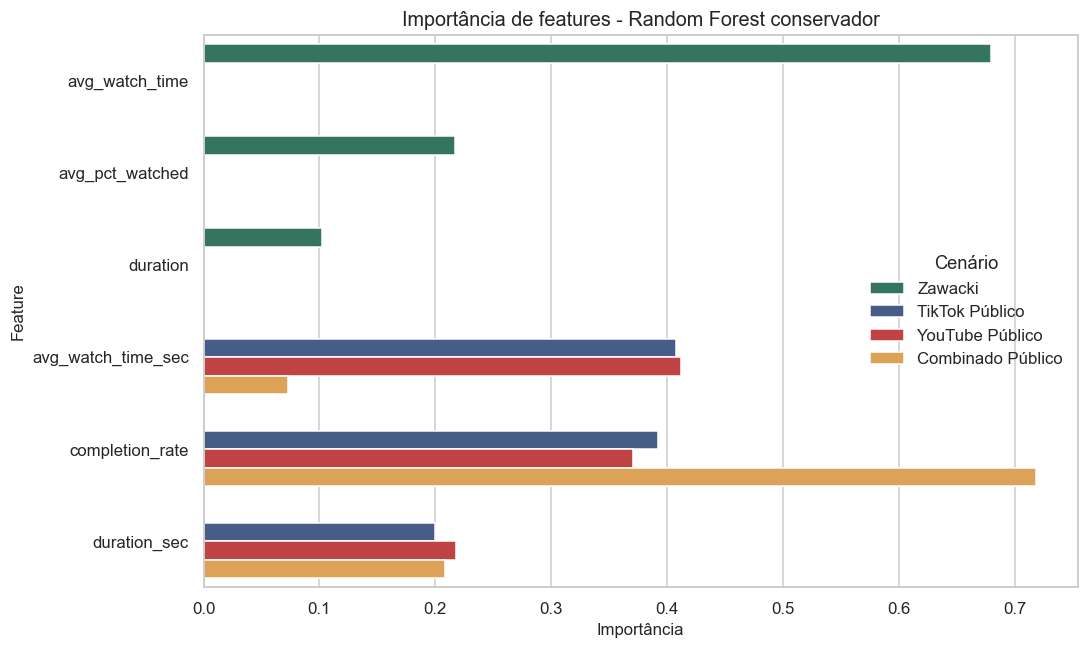

In [24]:
# [Código] Extração e visualização do feature_importances_ do Random Forest para os 4 cenários
# A interpretação principal utiliza o RF conservador; importâncias sem validação adequada não provam influência causal.

def extrair_importancias_rf(resultado, modelo, configuracao):
    return pd.DataFrame({'Cenário': resultado['cenario'], 'Feature': resultado['features'],
                         'Importância RF': modelo.feature_importances_, 'Configuração': configuracao}).sort_values('Importância RF', ascending=False)

importancias_rf_a_priori = pd.concat([
    extrair_importancias_rf(res, res['modelos']['Random Forest'], 'RF a priori') for res in resultados_modelos.values()
], ignore_index=True)
importancias_rf = pd.concat([
    extrair_importancias_rf(res, modelos_rf_conservadores[cenario], 'RF conservador') for cenario, res in resultados_modelos.items()
], ignore_index=True)

print('Insight 5 - Importância das features via Random Forest conservador')
display(importancias_rf.round(6))
print('Referência: importâncias do Random Forest a priori antes da mitigação de sobreajuste')
display(importancias_rf_a_priori.round(6))

for cenario, grupo in importancias_rf.groupby('Cenário'):
    top = grupo.sort_values('Importância RF', ascending=False).iloc[0]
    cv_rf = sensibilidade_regularizacao[(sensibilidade_regularizacao['Cenário'] == cenario) & (sensibilidade_regularizacao['Modelo'] == 'Random Forest conservador')]['CV R²'].iloc[0]
    qualificacao = 'interpretar apenas descritivamente' if cv_rf < 0.10 else 'interpretar com cautela, sem causalidade'
    print(f'{cenario}: feature mais importante = {top["Feature"]} (importância = {top["Importância RF"]:.4f}; CV R² RF = {cv_rf:.4f}; {qualificacao})')

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importancias_rf, x='Importância RF', y='Feature', hue='Cenário', ax=ax)
ax.set_title('Importância de features - Random Forest conservador')
ax.set_xlabel('Importância')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

# [Markdown] Seção 9 - Previsão de Duração Ótima: interpretação corrigida

A duração ótima não é uma constante observada nos dados; ela depende do modelo e da hipótese de retenção imposta à simulação. O Random Forest conservador é usado nesta seção para reduzir sobreajuste diagnosticado anteriormente, e a grade é limitada à faixa efetivamente observada em cada cenário.

Duas simulações são deliberadamente separadas:

- Retenção mediana: mantém as métricas de retenção na mediana do cenário. É a análise de sensibilidade mais comparável a versões anteriores do código, nas quais surgiram estimativas próximas de 53s.
- Boa retenção condicional: fixa retenção relativa no percentil 75 e deriva o tempo assistido coerentemente. Ela responde à pergunta solicitada de maximizar engajamento mantendo boa retenção, mas é hipotética: vídeos longos nem sempre conseguem atingir esse nível de retenção.

Por isso, o notebook imprime ambas, aplica bootstrap ao estudo Zawacki e não emite recomendação operacional para cenários cujo RF não generaliza ou cujo resultado agregado é confundido por plataforma.

In [25]:
# [Código] Predição via Random Forest conservador na faixa de duração observada
# Separar os modos evidencia quanto a duração ótima depende da premissa de retenção.

def gerar_grade_duracao(resultado, modelo, modo='retencao_mediana', retention_quantile=0.75):
    dados, features, target = resultado['data'], resultado['features'], resultado['target']
    dur_col = 'duration' if 'duration' in features else 'duration_sec'
    duracoes = np.arange(math.ceil(dados[dur_col].min()), math.floor(dados[dur_col].max()) + 1)
    base = dados[features].median(numeric_only=True)
    linhas = []
    for duracao in duracoes:
        linha = base.copy()
        linha[dur_col] = duracao
        if modo == 'retencao_boa':
            if {'avg_pct_watched', 'avg_watch_time'}.issubset(features):
                ret = dados['avg_pct_watched'].quantile(retention_quantile)
                linha['avg_pct_watched'] = ret
                linha['avg_watch_time'] = duracao * (ret / 100)
            elif {'completion_rate', 'avg_watch_time_sec'}.issubset(features):
                ret = dados['completion_rate'].quantile(retention_quantile)
                linha['completion_rate'] = ret
                linha['avg_watch_time_sec'] = duracao * ret
        linhas.append(linha.to_dict())
    grade = pd.DataFrame(linhas)[features]
    grade[f'{target}_previsto'] = modelo.predict(grade)
    grade['Cenário'] = resultado['cenario']
    grade['Modo'] = modo
    grade['duration_grid'] = duracoes
    return grade

previsoes_duracao = []
for cenario, resultado in resultados_modelos.items():
    modelo_rf = modelos_rf_conservadores[cenario]
    previsoes_duracao.append(gerar_grade_duracao(resultado, modelo_rf, modo='retencao_mediana'))
    previsoes_duracao.append(gerar_grade_duracao(resultado, modelo_rf, modo='retencao_boa', retention_quantile=0.75))
previsoes_duracao_df = pd.concat(previsoes_duracao, ignore_index=True)

print('Grades geradas apenas na faixa de duração observada, usando Random Forest conservador.')
display(previsoes_duracao_df.head())

Grades geradas apenas na faixa de duração observada, usando Random Forest conservador.


,duration,avg_pct_watched,avg_watch_time,er_likes_previsto,Cenário,Modo,duration_grid,duration_sec,completion_rate,avg_watch_time_sec,engagement_rate_previsto
0,9.0,41.7332,21.75,9.7137,Zawacki,retencao_mediana,9,NaN,NaN,NaN,NaN
1,10.0,41.7332,21.75,9.7137,Zawacki,retencao_mediana,10,NaN,NaN,NaN,NaN
2,11.0,41.7332,21.75,9.7137,Zawacki,retencao_mediana,11,NaN,NaN,NaN,NaN
3,12.0,41.7332,21.75,9.7137,Zawacki,retencao_mediana,12,NaN,NaN,NaN,NaN
4,13.0,41.7332,21.75,9.7137,Zawacki,retencao_mediana,13,NaN,NaN,NaN,NaN


Insight 4 - Pontos máximos condicionais via Random Forest conservador


,Cenário,Modo,Duração ótima prevista (s),Engajamento previsto,CV R² RF conservador,Validade
0,Zawacki,retencao_mediana,54,10.1876,0.2181,Sensibilidade com retenção mediana; não é regr...
1,Zawacki,retencao_boa,59,11.9750,0.2181,Hipótese condicional; reportar com bootstrap e...
2,TikTok Público,retencao_mediana,5,0.0940,-0.0032,Não recomendável: RF sem generalização validada.
3,TikTok Público,retencao_boa,9,0.0968,-0.0032,Não recomendável: RF sem generalização validada.
4,YouTube Público,retencao_mediana,83,0.0519,-0.0039,Não recomendável: RF sem generalização validada.
5,YouTube Público,retencao_boa,18,0.0517,-0.0039,Não recomendável: RF sem generalização validada.
6,Combinado Público,retencao_mediana,5,0.0828,0.1660,Não recomendar isoladamente: resultado confund...
7,Combinado Público,retencao_boa,5,0.0891,0.1660,Não recomendar isoladamente: resultado confund...


Estabilidade bootstrap da duração ótima - Zawacki (100 reamostragens)


,Modo,mediana,ic95_inferior,ic95_superior
0,retencao_boa,58.5,42.0,95.0
1,retencao_mediana,56.0,47.0,95.0


Leitura para a banca: um ponto ótimo só é defensável como estimativa condicional quando acompanhado deste intervalo de estabilidade.


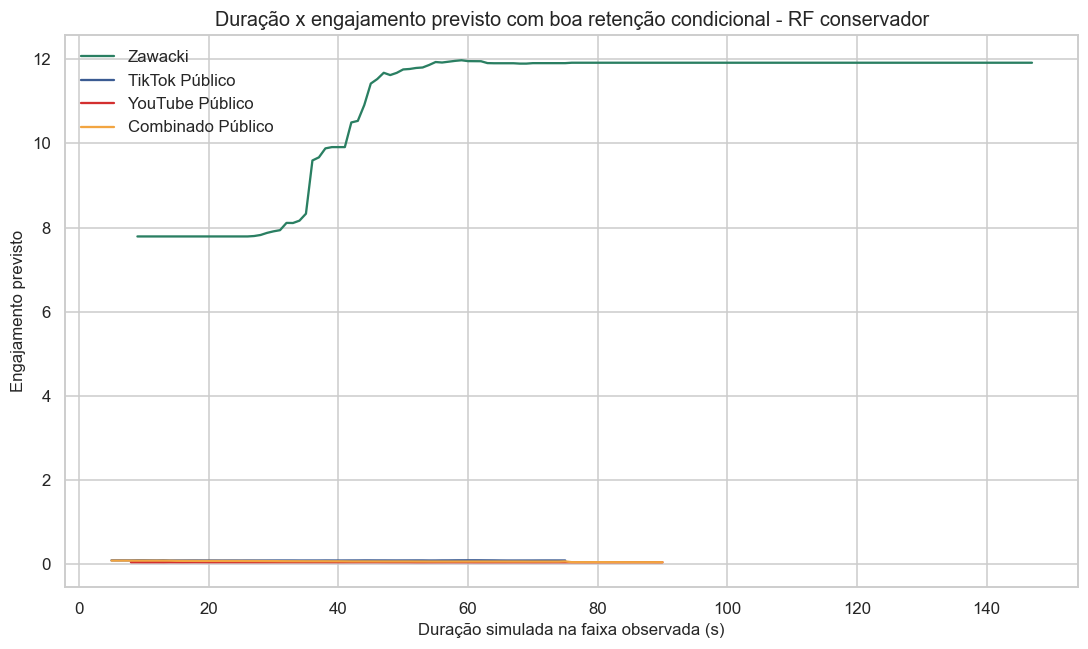

In [26]:
# [Código] Identificação do ponto ótimo condicional e estabilidade bootstrap no Zawacki
# O bootstrap mostra se um único valor de duração é estável diante da pequena amostra de 48 vídeos.

otimos = []
for cenario, resultado in resultados_modelos.items():
    pred_col = f'{resultado["target"]}_previsto'
    cv_rf = sensibilidade_regularizacao[(sensibilidade_regularizacao['Cenário'] == cenario) & (sensibilidade_regularizacao['Modelo'] == 'Random Forest conservador')]['CV R²'].iloc[0]
    for modo in ['retencao_mediana', 'retencao_boa']:
        grade = previsoes_duracao_df[(previsoes_duracao_df['Cenário'] == cenario) & (previsoes_duracao_df['Modo'] == modo)]
        melhor = grade.loc[grade[pred_col].idxmax()]
        if cenario in ['TikTok Público', 'YouTube Público'] or cv_rf < 0:
            validade = 'Não recomendável: RF sem generalização validada.'
        elif cenario == 'Combinado Público':
            validade = 'Não recomendar isoladamente: resultado confundido por plataforma.'
        elif modo == 'retencao_boa':
            validade = 'Hipótese condicional; reportar com bootstrap e cautela.'
        else:
            validade = 'Sensibilidade com retenção mediana; não é regra causal.'
        otimos.append({'Cenário': cenario, 'Modo': modo, 'Duração ótima prevista (s)': melhor['duration_grid'],
                       'Engajamento previsto': melhor[pred_col], 'CV R² RF conservador': cv_rf, 'Validade': validade})

otimos_duracao = pd.DataFrame(otimos)
print('Insight 4 - Pontos máximos condicionais via Random Forest conservador')
display(otimos_duracao.round(6))

# Bootstrap somente no estudo de caso, cuja amostra pequena torna a incerteza especialmente importante.
def bootstrap_otimo_zawacki(n_bootstrap=100):
    resultado = resultados_modelos['Zawacki']
    dados, features, target = resultado['data'], resultado['features'], resultado['target']
    duracoes = np.arange(math.ceil(dados['duration'].min()), math.floor(dados['duration'].max()) + 1)
    rng = np.random.default_rng(RANDOM_STATE)
    registros = []
    for modo in ['retencao_mediana', 'retencao_boa']:
        for b in range(n_bootstrap):
            amostra = dados.iloc[rng.integers(0, len(dados), len(dados))].copy()
            modelo = definir_ensembles_conservadores(len(amostra), random_state=RANDOM_STATE + b)['Random Forest conservador']
            modelo.fit(amostra[features], amostra[target])
            base = amostra[features].median(numeric_only=True)
            linhas = []
            for duracao in duracoes:
                linha = base.copy()
                linha['duration'] = duracao
                if modo == 'retencao_boa':
                    ret = amostra['avg_pct_watched'].quantile(0.75)
                    linha['avg_pct_watched'] = ret
                    linha['avg_watch_time'] = duracao * (ret / 100)
                linhas.append(linha.to_dict())
            X_grade = pd.DataFrame(linhas)[features]
            duracao_otima = duracoes[np.argmax(modelo.predict(X_grade))]
            registros.append({'Modo': modo, 'Duração ótima (s)': duracao_otima})
    return pd.DataFrame(registros)

bootstrap_otimos_z = bootstrap_otimo_zawacki(n_bootstrap=100)
resumo_bootstrap_z = bootstrap_otimos_z.groupby('Modo')['Duração ótima (s)'].agg(
    mediana='median',
    ic95_inferior=lambda s: s.quantile(0.025),
    ic95_superior=lambda s: s.quantile(0.975)
).reset_index()
print('Estabilidade bootstrap da duração ótima - Zawacki (100 reamostragens)')
display(resumo_bootstrap_z.round(2))
print('Leitura para a banca: um ponto ótimo só é defensável como estimativa condicional quando acompanhado deste intervalo de estabilidade.')

otimos_principais = otimos_duracao[otimos_duracao['Modo'] == 'retencao_boa'].copy()

fig, ax = plt.subplots(figsize=(10, 6))
for cenario, resultado in resultados_modelos.items():
    pred_col = f'{resultado["target"]}_previsto'
    sub = previsoes_duracao_df[(previsoes_duracao_df['Cenário'] == cenario) & (previsoes_duracao_df['Modo'] == 'retencao_boa')]
    ax.plot(sub['duration_grid'], sub[pred_col], label=cenario)
ax.set_title('Duração x engajamento previsto com boa retenção condicional - RF conservador')
ax.set_xlabel('Duração simulada na faixa observada (s)')
ax.set_ylabel('Engajamento previsto')
ax.legend()
plt.tight_layout()
plt.show()

# [Markdown] Seção 10 - Clustering K-Means

# [Markdown] Justificativa: clustering como análise descritiva, não preditiva

O K-Means é usado apenas como análise descritiva para identificar perfis de vídeos com combinações semelhantes de duração, retenção e engajamento. Ele não é usado para inferir causalidade, selecionar o melhor modelo nem substituir a validação supervisionada. Como as variáveis possuem escalas diferentes, StandardScaler é aplicado antes do agrupamento. O número k=3 foi escolhido para alinhar a exploração aos três regimes de duração usados no estudo, não por otimização pós-hoc.

In [27]:
# [Código] K-Means com StandardScaler, k=3, no Zawacki
# Clusters descrevem perfis de vídeos no estudo de caso real.

cluster_features_z = ['duration', 'avg_pct_watched', 'avg_watch_time', 'er_likes']
scaler_z = StandardScaler()
X_cluster_z = scaler_z.fit_transform(df_zawacki[cluster_features_z])

kmeans_z = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20)
df_zawacki_clusters = df_zawacki.copy()
df_zawacki_clusters['cluster'] = kmeans_z.fit_predict(X_cluster_z)

perfil_clusters_z = (
    df_zawacki_clusters.groupby('cluster')[cluster_features_z]
    .agg(['count', 'mean', 'median'])
    .round(4)
)

print('Clusters K-Means - Dataset A')
display(perfil_clusters_z)

Clusters K-Means - Dataset A


duration                    avg_pct_watched                   avg_watch_time                 er_likes                  
           count      mean   median           count     mean   median          count     mean median    count     mean   median
cluster                                                                                                                        
0             21   47.1576   46.880              21  57.7573  54.9884             21  25.3667   25.1       21  10.6002  10.8883
1             23   54.1709   55.750              23  32.0915  31.3690             23  16.4578   16.4       23   7.6729   7.1708
2              4  127.0850  126.765               4  42.1362  41.7332              4  53.0750   52.8        4  15.1235  15.5895

In [28]:
# [Código] K-Means no Dataset Público
# A amostra de ML mantém o procedimento rápido e reprodutível no dataset em escala.

cluster_features_public = ['duration_sec', 'completion_rate', 'avg_watch_time_sec', 'engagement_rate']
scaler_public = StandardScaler()
X_cluster_public = scaler_public.fit_transform(df_public_ml[cluster_features_public])

kmeans_public = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20)
df_public_clusters = df_public_ml.copy()
df_public_clusters['cluster'] = kmeans_public.fit_predict(X_cluster_public)

perfil_clusters_public = (
    df_public_clusters.groupby('cluster')[cluster_features_public]
    .agg(['count', 'mean', 'median'])
    .round(5)
)

print('Clusters K-Means - Dataset B público')
display(perfil_clusters_public)

print('Distribuição de clusters por plataforma')
display(pd.crosstab(df_public_clusters['platform'], df_public_clusters['cluster'], normalize='index').round(4))

Clusters K-Means - Dataset B público


duration_sec                 completion_rate                avg_watch_time_sec                 engagement_rate                
               count     mean median           count    mean median              count     mean median           count    mean  median
cluster                                                                                                                               
0               6022  25.8482   25.0            6022  0.7107  0.721               6022  18.3370   17.8            6022  0.0979  0.0956
1               5773  30.0736   30.0            5773  0.5535  0.550               5773  16.4416   16.4            5773  0.0581  0.0565
2               3205  58.7725   56.0            3205  0.6489  0.657               3205  37.6281   35.5            3205  0.0658  0.0617

Distribuição de clusters por plataforma


cluster,0,1,2
platform,,,
TikTok,0.6274,0.2242,0.1484
YouTube,0.0584,0.6288,0.3128


# [Markdown] Seção 11 - Análise Comparativa Final

In [29]:
# [Código] Tabela consolidada de modelos x cenários
# Esta tabela compara desempenho preditivo e torna visível o gap que caracteriza sobreajuste.

tabela_modelos_consolidada = pd.concat([res['tabela'] for res in resultados_modelos.values()], ignore_index=True)
print('Insight 3 - Comparativo entre modelos de ML com R², CV R² e diagnóstico de sobreajuste')
display(tabela_modelos_consolidada.sort_values(['Cenário', 'CV R²'], ascending=[True, False]).style.format({
    'R² treino': '{:.4f}', 'CV R²': '{:.4f}', 'Gap treino-CV': '{:.4f}',
    'MAE treino': '{:.4f}', 'MAE CV': '{:.4f}', 'RMSE CV': '{:.4f}'
}))

melhores_por_cenario = tabela_modelos_consolidada.loc[tabela_modelos_consolidada.groupby('Cenário')['CV R²'].idxmax()].reset_index(drop=True)
print('Melhores CV R² por cenário, acompanhados do diagnóstico obrigatório:')
display(melhores_por_cenario[['Cenário', 'Modelo', 'CV R²', 'R² treino', 'Gap treino-CV', 'Diagnóstico', 'Validação']].round(6))

print('Sensibilidade com ensembles conservadores (não substitui seleção a priori):')
display(sensibilidade_regularizacao.style.format({'R² treino': '{:.4f}', 'CV R²': '{:.4f}', 'Gap treino-CV': '{:.4f}'}))

Insight 3 - Comparativo entre modelos de ML com R², CV R² e diagnóstico de sobreajuste


,Cenário,Modelo,n,Validação,R² treino,CV R²,Gap treino-CV,MAE treino,MAE CV,RMSE CV,Diagnóstico
12,Combinado Público,Gradient Boosting,15000,5-fold CV,0.1758,0.1662,0.0096,0.0217,0.0218,0.0276,Sem alerta forte de sobreajuste
13,Combinado Público,Ridge,15000,5-fold CV,0.1141,0.1132,0.0008,0.0226,0.0226,0.0285,Sem alerta forte de sobreajuste
14,Combinado Público,Linear,15000,5-fold CV,0.1141,0.1132,0.0008,0.0226,0.0226,0.0285,Sem alerta forte de sobreajuste
15,Combinado Público,Random Forest,15000,5-fold CV,0.3585,0.0847,0.2738,0.0189,0.0228,0.0289,"Atenção: gap moderado (>= 0,15)"
4,TikTok Público,Ridge,9044,5-fold CV,0.0002,-0.0006,0.0008,0.0207,0.0207,0.0261,Sem generalização validada (CV R² < 0)
5,TikTok Público,Linear,9044,5-fold CV,0.0002,-0.0006,0.0008,0.0207,0.0207,0.0261,Sem generalização validada (CV R² < 0)
6,TikTok Público,Gradient Boosting,9044,5-fold CV,0.0147,-0.0057,0.0204,0.0206,0.0208,0.0261,Sem generalização validada (CV R² < 0)
7,TikTok Público,Random Forest,9044,5-fold CV,0.2431,-0.1013,0.3444,0.0179,0.0218,0.0273,Sem generalização validada (CV R² < 0)
8,YouTube Público,Ridge,5956,5-fold CV,0.0003,-0.0008,0.0011,0.0128,0.0128,0.0158,Sem generalização validada (CV R² < 0)
9,YouTube Público,Linear,5956,5-fold CV,0.0003,-0.0008,0.0011,0.0128,0.0128,0.0158,Sem generalização validada (CV R² < 0)


Melhores CV R² por cenário, acompanhados do diagnóstico obrigatório:


,Cenário,Modelo,CV R²,R² treino,Gap treino-CV,Diagnóstico,Validação
0,Combinado Público,Gradient Boosting,0.1662,0.1758,0.0096,Sem alerta forte de sobreajuste,5-fold CV
1,TikTok Público,Ridge,-0.0006,0.0002,0.0008,Sem generalização validada (CV R² < 0),5-fold CV
2,YouTube Público,Ridge,-0.0008,0.0003,0.0011,Sem generalização validada (CV R² < 0),5-fold CV
3,Zawacki,Gradient Boosting,0.2385,0.8612,0.6227,"Sobreajuste forte (gap >= 0,30)",LOOCV


Sensibilidade com ensembles conservadores (não substitui seleção a priori):


,Cenário,Modelo,Validação,R² treino,CV R²,Gap treino-CV,Diagnóstico
0,Combinado Público,Random Forest conservador,5-fold CV,0.1746,0.1660,0.0086,Sem alerta forte de sobreajuste
1,Combinado Público,Gradient Boosting conservador,5-fold CV,0.1305,0.1287,0.0017,Sem alerta forte de sobreajuste
2,TikTok Público,Gradient Boosting conservador,5-fold CV,0.0017,-0.0008,0.0024,Sem generalização validada (CV R² < 0)
3,TikTok Público,Random Forest conservador,5-fold CV,0.0138,-0.0032,0.0170,Sem generalização validada (CV R² < 0)
4,YouTube Público,Gradient Boosting conservador,5-fold CV,0.0024,-0.0011,0.0035,Sem generalização validada (CV R² < 0)
5,YouTube Público,Random Forest conservador,5-fold CV,0.0178,-0.0039,0.0217,Sem generalização validada (CV R² < 0)
6,Zawacki,Gradient Boosting conservador,LOOCV,0.4490,0.2415,0.2075,"Atenção: gap moderado (>= 0,15)"
7,Zawacki,Random Forest conservador,LOOCV,0.4039,0.2181,0.1858,"Atenção: gap moderado (>= 0,15)"


In [30]:
# [Código] Resumo de insights agregados
# A célula consolida conclusões e cautelas para impedir que resultados exploratórios sejam reportados como causalidade.

insights = []
for item in correlacoes_zawacki + correlacoes_publico:
    insights.append({'Insight': item['analise'], 'Resultado': f"r={item['r']:.4f}, p={item['p_value']:.6g}, {item['significancia']}, n={item['n']}"})

for _, row in melhores_por_cenario.iterrows():
    insights.append({'Insight': f'Insight 3 - Melhor CV em {row["Cenário"]}',
                     'Resultado': f"{row['Modelo']}; CV R²={row['CV R²']:.4f}; gap={row['Gap treino-CV']:.4f}; {row['Diagnóstico']}"})

for _, row in otimos_principais.iterrows():
    insights.append({'Insight': f'Insight 4 - Duração ótima condicional em {row["Cenário"]}',
                     'Resultado': f"{row['Duração ótima prevista (s)']:.0f}s; previsto={row['Engajamento previsto']:.6f}; {row['Validade']}"})

for cenario, grupo in importancias_rf.groupby('Cenário'):
    top = grupo.sort_values('Importância RF', ascending=False).iloc[0]
    insights.append({'Insight': f'Insight 5 - Top feature RF conservador em {cenario}', 'Resultado': f"{top['Feature']} ({top['Importância RF']:.4f})"})

for categoria, row in retencao_por_categoria_z.iterrows():
    insights.append({'Insight': f'Insight 6 - Retenção média Zawacki: {categoria}', 'Resultado': f"avg_pct_watched={row['retencao_media_pct']:.4f}; n={int(row['n'])}"})
for plataforma, valor in engagement_por_plataforma.items():
    insights.append({'Insight': f'Insight 7 - Engagement rate médio: {plataforma}', 'Resultado': f'{valor:.6f}'})
for plataforma, row in completion_engagement_por_plataforma.iterrows():
    insights.append({'Insight': f'Insight 8 - Completion x engagement: {plataforma}', 'Resultado': f"completion={row['completion_rate']:.6f}; engagement={row['engagement_rate']:.6f}"})

insights.append({'Insight': 'Robustez - Confundimento Dataset B', 'Resultado': 'O padrão agregado não se mantém dentro de TikTok/YouTube; controlar plataforma é obrigatório.'})
insights.append({'Insight': 'Robustez - Engajamento por categoria Zawacki', 'Resultado': 'Kruskal-Wallis deve ser consultado antes de afirmar que longos engajam mais.'})

resumo_insights = pd.DataFrame(insights)
print('Resumo consolidado dos insights e cautelas')
display(resumo_insights)

Resumo consolidado dos insights e cautelas

,Insight,Resultado
0,Insight 1A - Duração x retenção relativa (Zawa...,"r=-0.4095, p=0.00385243, **, n=48"
1,Insight 2A - Duração x engajamento (Zawacki),"r=0.3431, p=0.016971, *, n=48"
2,Insight 9A - Retenção relativa x engajamento (...,"r=0.2473, p=0.0901864, ns, n=48"
3,Watch time absoluto x engajamento (Zawacki),"r=0.5432, p=6.62488e-05, ***, n=48"
4,Insight 1B - Duração x completion rate (geral),"r=-0.1348, p=1.23916e-193, ***, n=48079"
5,Insight 9B - Completion rate x engagement rate...,"r=0.2989, p=0, ***, n=48079"
6,Insight 1B - Duração x completion rate (TikTok),"r=0.0041, p=0.481062, ns, n=28844"
7,Insight 8/9B - Completion x engagement (TikTok),"r=0.0087, p=0.139273, ns, n=28844"
8,Insight 1B - Duração x completion rate (YouTube),"r=0.0092, p=0.203707, ns, n=19235"
9,Insight 8/9B - Completion x engagement (YouTube),"r=0.0023, p=0.745902, ns, n=19235"


# [Markdown] Seção 12 - Geração de Dashboards (PNG)

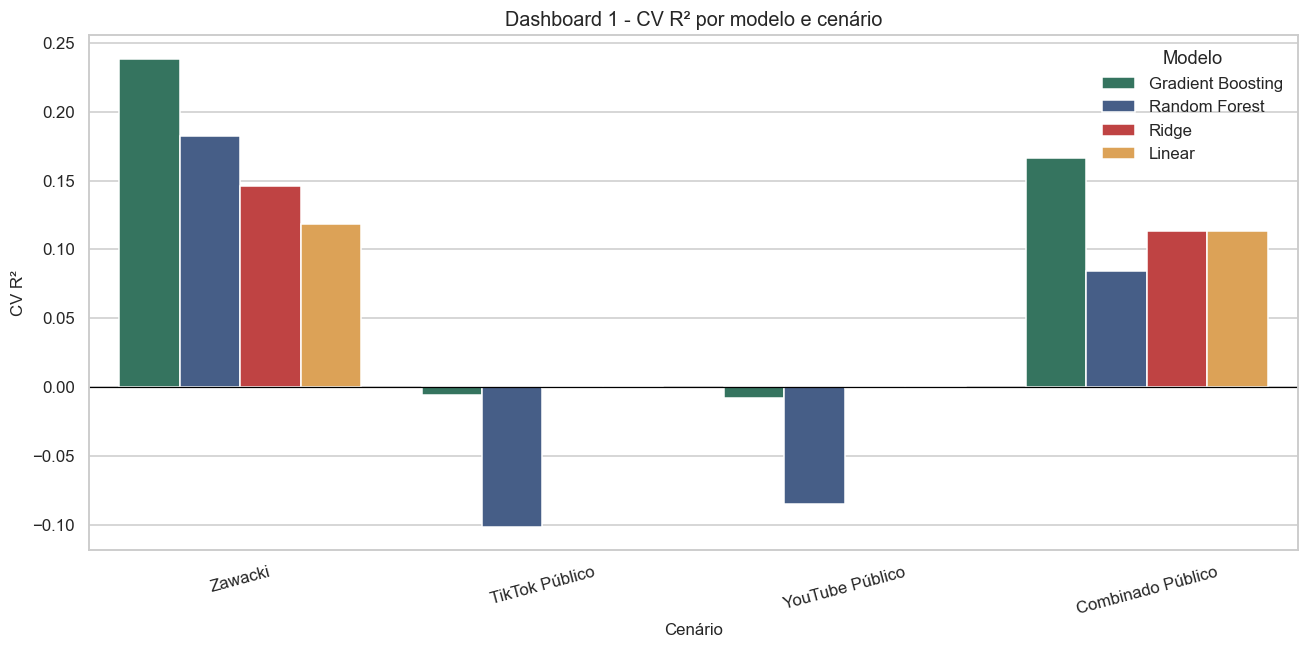

Dashboard salvo em: C:\Users\Pichau\OneDrive\Documentos\TCC\Projeto Final\outputs\dashboard_1_modelos_cenarios.png


In [31]:
# [Código] Dashboard 1 (Modelos x Cenários)
# Salva um resumo visual de CV R² para comparação entre modelos.

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=tabela_modelos_consolidada, x='Cenário', y='CV R²', hue='Modelo', ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Dashboard 1 - CV R² por modelo e cenário')
ax.set_xlabel('Cenário')
ax.set_ylabel('CV R²')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
path_dashboard_1 = OUTPUT_DIR / 'dashboard_1_modelos_cenarios.png'
plt.savefig(path_dashboard_1, bbox_inches='tight')
plt.show()
print(f'Dashboard salvo em: {path_dashboard_1}')

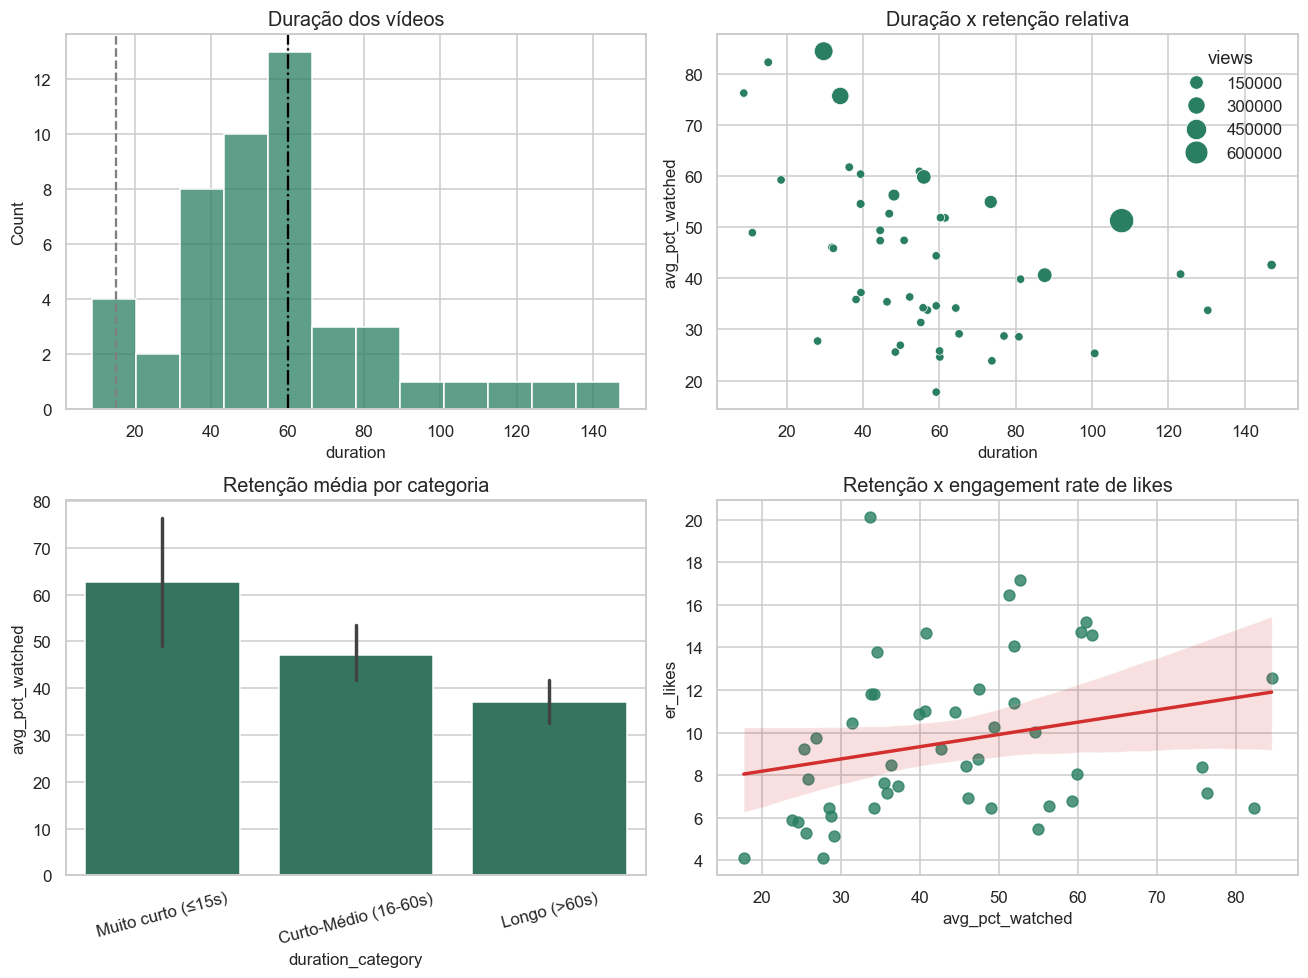

Dashboard salvo em: C:\Users\Pichau\OneDrive\Documentos\TCC\Projeto Final\outputs\dashboard_2_zawacki_aprofundado.png


In [32]:
# [Código] Dashboard 2 (Zawacki aprofundado)
# Integra distribuição, retenção por categoria e relação retenção-engajamento no estudo de caso.

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.histplot(data=df_zawacki, x='duration', bins=12, ax=axes[0, 0], color=PALETTE['Zawacki'])
axes[0, 0].axvline(15, color='gray', linestyle='--')
axes[0, 0].axvline(60, color='black', linestyle='-.')
axes[0, 0].set_title('Duração dos vídeos')

sns.scatterplot(data=df_zawacki, x='duration', y='avg_pct_watched', size='views', sizes=(30, 250), ax=axes[0, 1], color=PALETTE['Zawacki'])
axes[0, 1].set_title('Duração x retenção relativa')

sns.barplot(data=df_zawacki, x='duration_category', y='avg_pct_watched', ax=axes[1, 0], color=PALETTE['Zawacki'])
axes[1, 0].set_title('Retenção média por categoria')
axes[1, 0].tick_params(axis='x', rotation=15)

sns.regplot(data=df_zawacki, x='avg_pct_watched', y='er_likes', ax=axes[1, 1], scatter_kws={'s': 50}, line_kws={'color': '#D32F2F'})
axes[1, 1].set_title('Retenção x engagement rate de likes')

plt.tight_layout()
path_dashboard_2 = OUTPUT_DIR / 'dashboard_2_zawacki_aprofundado.png'
plt.savefig(path_dashboard_2, bbox_inches='tight')
plt.show()
print(f'Dashboard salvo em: {path_dashboard_2}')

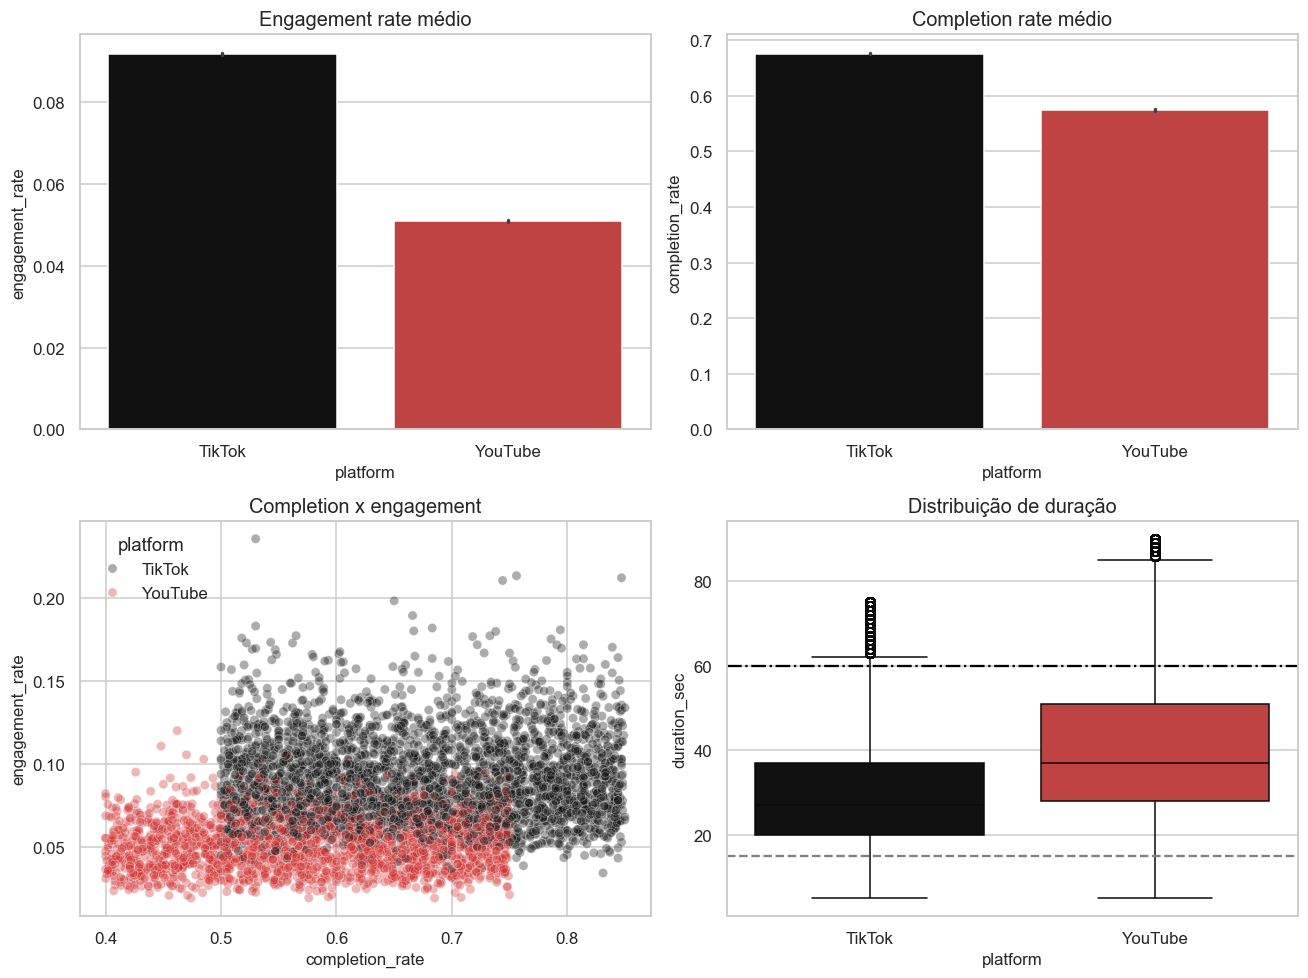

Dashboard salvo em: C:\Users\Pichau\OneDrive\Documentos\TCC\Projeto Final\outputs\dashboard_3_tiktok_vs_youtube.png


In [33]:
# [Código] Dashboard 3 (TikTok vs YouTube comparativo)
# Resume diferenças de retenção, engajamento e duração entre plataformas.

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.barplot(data=df_public_clean, x='platform', y='engagement_rate', errorbar=('ci', 95), palette=PALETTE, ax=axes[0, 0])
axes[0, 0].set_title('Engagement rate médio')

sns.barplot(data=df_public_clean, x='platform', y='completion_rate', errorbar=('ci', 95), palette=PALETTE, ax=axes[0, 1])
axes[0, 1].set_title('Completion rate médio')

sns.scatterplot(data=df_public_clean.sample(min(5000, len(df_public_clean)), random_state=RANDOM_STATE), x='completion_rate', y='engagement_rate', hue='platform', alpha=0.35, palette=PALETTE, ax=axes[1, 0])
axes[1, 0].set_title('Completion x engagement')

sns.boxplot(data=df_public_clean, x='platform', y='duration_sec', palette=PALETTE, ax=axes[1, 1])
axes[1, 1].axhline(15, color='gray', linestyle='--')
axes[1, 1].axhline(60, color='black', linestyle='-.')
axes[1, 1].set_title('Distribuição de duração')

plt.tight_layout()
path_dashboard_3 = OUTPUT_DIR / 'dashboard_3_tiktok_vs_youtube.png'
plt.savefig(path_dashboard_3, bbox_inches='tight')
plt.show()
print(f'Dashboard salvo em: {path_dashboard_3}')

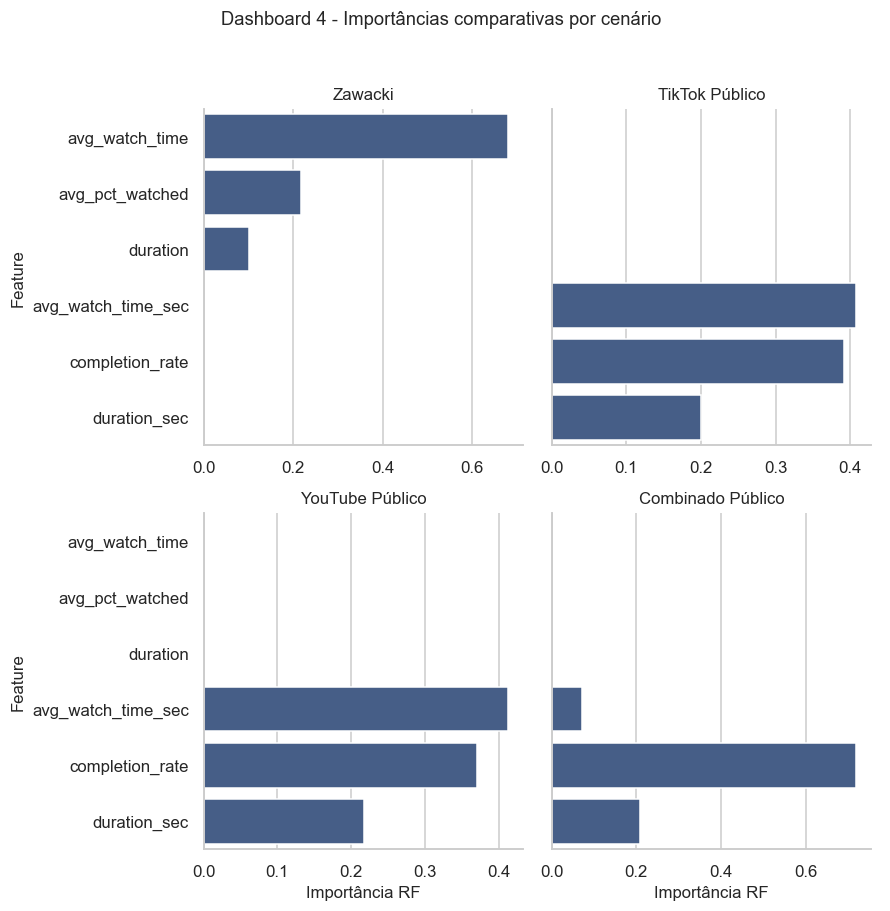

Dashboard salvo em: C:\Users\Pichau\OneDrive\Documentos\TCC\Projeto Final\outputs\dashboard_4_importancias_comparativas.png


In [34]:
# [Código] Dashboard 4 (Importâncias comparativas)
# Consolida as importâncias do Random Forest em facetas por cenário.

g = sns.catplot(
    data=importancias_rf,
    x='Importância RF',
    y='Feature',
    col='Cenário',
    kind='bar',
    col_wrap=2,
    height=4,
    sharex=False,
    color='#3B5B92'
)
g.set_titles('{col_name}')
g.set_axis_labels('Importância RF', 'Feature')
g.fig.suptitle('Dashboard 4 - Importâncias comparativas por cenário', y=1.03)
plt.tight_layout()
path_dashboard_4 = OUTPUT_DIR / 'dashboard_4_importancias_comparativas.png'
g.fig.savefig(path_dashboard_4, bbox_inches='tight', dpi=300)
plt.show()
print(f'Dashboard salvo em: {path_dashboard_4}')

# [Markdown] Conclusão e limitações do estudo

Este notebook produz um pipeline reprodutível para analisar duração, retenção e engajamento em vídeos verticais, mantendo Pearson como análise principal previamente especificada e acrescentando testes de robustez para sustentar uma defesa metodologicamente honesta.

As principais limitações e decisões de interpretação são:

- O Dataset A possui n=48; LOOCV reduz desperdício de amostra, mas não elimina instabilidade. A categoria ≤15s contém somente dois vídeos.
- Gaps grandes entre R² de treino e CV R² caracterizam sobreajuste de ensembles flexíveis; por isso foi adicionada análise pós-diagnóstico com ensembles conservadores.
- Uma correlação significativa em Pearson que não se mantém em Spearman deve ser descrita como sensível à especificação, não como lei geral.
- No Dataset B, resultados agregados podem refletir diferenças estruturais entre plataformas. A inferência sobre influência de retenção exige leitura estratificada e controle por plataforma.
- Features de retenção absoluta e relativa são relacionadas matematicamente à duração; importâncias não representam efeito causal independente.
- O Dataset B inclui variáveis estimadas/sintéticas segundo seu dicionário oficial; ele apoia validação operacional, não inferência causal.
- A duração ótima é uma simulação condicional ao modelo e ao nível de retenção imposto. Ela deve ser apresentada acompanhada de sensibilidade/bootstrap, nunca como recomendação universal.

Frase-síntese metodológica sugerida: A modelagem foi conduzida por seleção a priori de algoritmos, complementada por diagnósticos transparentes de sobreajuste, robustez e confundimento por plataforma, aumentando a reprodutibilidade das evidências sobre retenção e engajamento em vídeos verticais.